In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle

import xgboost as xgb

import seaborn as sns
import matplotlib.pyplot as plt

import shap
shap.initjs()  # Initialize JavaScript visualization support

import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/Users/ekkirinaldi/Documents/Git/ai-bearing-toto/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


./crwu-bearings-benchmarks-shap-explainability.ipynb
./ID-crwu-bearings-benchmarks-shap-explainability.ipynb.backup
./CWRU_48k_load_1_CNN_data.npz
./ID-crwu-bearings-benchmarks-dt-rf-xgb.ipynb
./ID-crwu-bearings-benchmarks-shap-explainability.ipynb
./feature_time_48k_2048_load_1.csv
./raw/OR007_6_1_136.mat
./raw/OR021_6_1_239.mat
./raw/Time_Normal_1_098.mat
./raw/IR021_1_214.mat
./raw/IR014_1_175.mat
./raw/IR007_1_110.mat
./raw/B021_1_227.mat
./raw/B014_1_190.mat
./raw/B007_1_123.mat
./raw/OR014_6_1_202.mat


## Ringkasan Eksekutif

Notebook ini mengimplementasikan benchmark dan analisis eksplainabilitas SHAP yang komprehensif untuk deteksi kerusakan bearing menggunakan Dataset Bearing CWRU dengan fokus pada model berbasis pohon (tree-based models).

**Ringkasan Dataset:**
- **Total Sampel**: 2.300 sampel dari 10 kelas kerusakan
- **Sampel per Kelas**: 230 sampel per jenis kerusakan (seimbang sempurna)
- **Pembagian Train-Test**: 1.550 sampel training (67,4%) / 750 sampel testing (32,6%)
- **Fitur**: 9 fitur statistik yang diekstrak dari sinyal getaran domain waktu

**Model yang Dibandingkan:**
- **Decision Tree**: Model pohon keputusan dasar dengan hyperparameter tuning
- **Random Forest**: Ensemble dari multiple decision trees
- **XGBoost**: Gradient boosting dengan optimasi lanjutan

**Analisis SHAP:**
- Analisis eksplainabilitas SHAP dilakukan pada subset 200 sampel untuk efisiensi komputasi
- Menggunakan TreeExplainer yang efisien untuk model berbasis pohon
- Penjelasan global dan lokal disediakan untuk ketiga model tree-based

**Tujuan:**
- Membandingkan performa tiga model tree-based untuk deteksi kerusakan bearing
- Menganalisis kepentingan fitur menggunakan SHAP values
- Mengidentifikasi pola spesifik kerusakan dan strategi pemantauan yang optimal


## Alur Kerja Penelitian

Diagram berikut menjelaskan alur kerja penelitian dari data mentah hingga interpretasi hasil:

```
┌─────────────────────────────────────────────────────────────────┐
│                    DATA PREPROCESSING                           │
│  Raw Vibration Signals (.mat files)                             │
│         ↓                                                       │
│  Feature Extraction (Time-domain)                               │
│  - max, min, mean, sd, rms, skewness, kurtosis, crest, form     │
│         ↓                                                       │
│  CSV Dataset (2300 samples × 10 features)                       │
└─────────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────────┐
│                    DATA EXPLORATION                             │
│  - Dataset shape & statistics                                   │
│  - Class distribution (10 fault types)                          │
│  - Feature statistics                                           │
└─────────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────────┐
│                    DATA PREPARATION                             │
│  Train-Test Split (1550 train / 750 test)                       │
│  Note: Tree models tidak memerlukan scaling                     │
└─────────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────────┐
│                    MODEL TRAINING                               │
│  ┌──────────────┐  ┌──────────────┐  ┌──────────────┐          │
│  │ Decision     │  │ Random       │  │ XGBoost      │          │
│  │ Tree         │  │ Forest       │  │              │          │
│  └──────────────┘  └──────────────┘  └──────────────┘          │
│         ↓                  ↓                  ↓                  │
│  Hyperparameter Tuning (GridSearchCV)                           │
└─────────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────────┐
│                    MODEL EVALUATION                             │
│  - Confusion Matrix (Training & Test)                            │
│  - Classification Report                                        │
│  - ROC Curves (DT, RF, XGB)                                    │
│  - Precision-Recall Curves                                     │
│  - Performance Comparison Table                                 │
└─────────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────────┐
│                    SHAP EXPLAINABILITY                          │
│  ┌──────────────┐  ┌──────────────┐  ┌──────────────┐          │
│  │ Decision     │  │ Random       │  │ XGBoost      │          │
│  │ Tree         │  │ Forest       │  │              │          │
│  │ TreeExplainer│  │ TreeExplainer│  │ TreeExplainer│          │
│  │ (200 samples)│  │ (200 samples)│  │ (200 samples)│          │
│  └──────────────┘  └──────────────┘  └──────────────┘          │
│         ↓                  ↓                  ↓                  │
│  ┌──────────────────────────────────────────┐                   │
│  │  SHAP Analysis                           │                   │
│  │  - Global Feature Importance (Summary)   │                   │
│  │  - Local Explanations (Waterfall)        │                   │
│  │  - Model Comparison                      │                   │
│  │  - Fault-Specific Analysis               │                   │
│  └──────────────────────────────────────────┘                   │
└─────────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────────┐
│                    INTERPRETATION & FINDINGS                    │
│  - Key Feature Insights                                         │
│  - Model Comparison Insights                                    │
│  - Fault-Specific Patterns                                      │
│  - Misclassification Analysis                                   │
└─────────────────────────────────────────────────────────────────┘
```

**Catatan Penting:**
- Analisis SHAP menggunakan subset 200 sampel untuk efisiensi komputasi
- TreeExplainer sangat efisien untuk model berbasis pohon (lebih cepat dari KernelExplainer)
- Evaluasi model final menggunakan seluruh 750 sampel test set
- Tree models tidak memerlukan feature scaling, namun scaling tetap dilakukan untuk konsistensi


## Identifikasi Jenis Kerusakan
Terdapat 10 jenis kerusakan yang terkait dengan setiap cacat bearing:

- **Ball_007_1**: Cacat pada bola (0.007 inci)
- **Ball_014_1**: Cacat pada bola (0.014 inci)
- **Ball_021_1**: Cacat pada bola (0.021 inci)
- **IR_007_1**: Kerusakan inner race (0.007 inci)
- **IR_014_1**: Kerusakan inner race (0.014 inci)
- **IR_021_1**: Kerusakan inner race (0.021 inci)
- **Normal_1**: Normal
- **OR_007_6_1**: Kerusakan outer race (0.007 inci, data dikumpulkan dari posisi jam 6)
- **OR_014_6_1**: Kerusakan outer race (0.014 inci, jam 6)
- **OR_021_6_1**: Kerusakan outer race (0.021 inci, jam 6)

## Mengambil Data
File yang akan kita baca adalah hasil preprocessing dari file data mentah (folder `raw/`).

Segmen time series berisi 2048 titik masing-masing. Mengingat frekuensi sampling adalah 48kHz, setiap time series mencakup 0.04 detik.

In [2]:
data_time = pd.read_csv("feature_time_48k_2048_load_1.csv")
data_time

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1
...,...,...,...,...,...,...,...,...,...,...
2295,0.21425,-0.19839,0.010769,0.064100,0.064983,-0.212497,-0.119312,3.297037,6.034174,Normal_1
2296,0.21967,-0.20882,0.013136,0.068654,0.069883,-0.061308,-0.295122,3.143410,5.319958,Normal_1
2297,0.20799,-0.21613,0.012571,0.067128,0.068279,-0.154754,-0.071405,3.046161,5.431299,Normal_1
2298,0.21425,-0.22405,0.012608,0.066813,0.067977,-0.326966,0.023662,3.151821,5.391672,Normal_1


## Analisis Data Eksploratif (EDA)

Mari kita eksplorasi dataset untuk memahami distribusi fitur, korelasi, dan keseimbangan kelas.


In [3]:
# Basic dataset information
print("Dataset shape:", data_time.shape)
print("\nColumn names:", data_time.columns.tolist())
print("\nData types:")
print(data_time.dtypes)
print("\nMissing values:")
print(data_time.isnull().sum().sum())
print("\nFirst few rows:")
data_time.head()


Dataset shape: (2300, 10)

Column names: ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form', 'fault']

Data types:
max         float64
min         float64
mean        float64
sd          float64
rms         float64
skewness    float64
kurtosis    float64
crest       float64
form        float64
fault        object
dtype: object

Missing values:
0

First few rows:


,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


Fault type distribution:
fault
Ball_007_1    230
Ball_014_1    230
Ball_021_1    230
IR_007_1      230
IR_014_1      230
IR_021_1      230
Normal_1      230
OR_007_6_1    230
OR_014_6_1    230
OR_021_6_1    230
Name: count, dtype: int64

Total samples: 2300


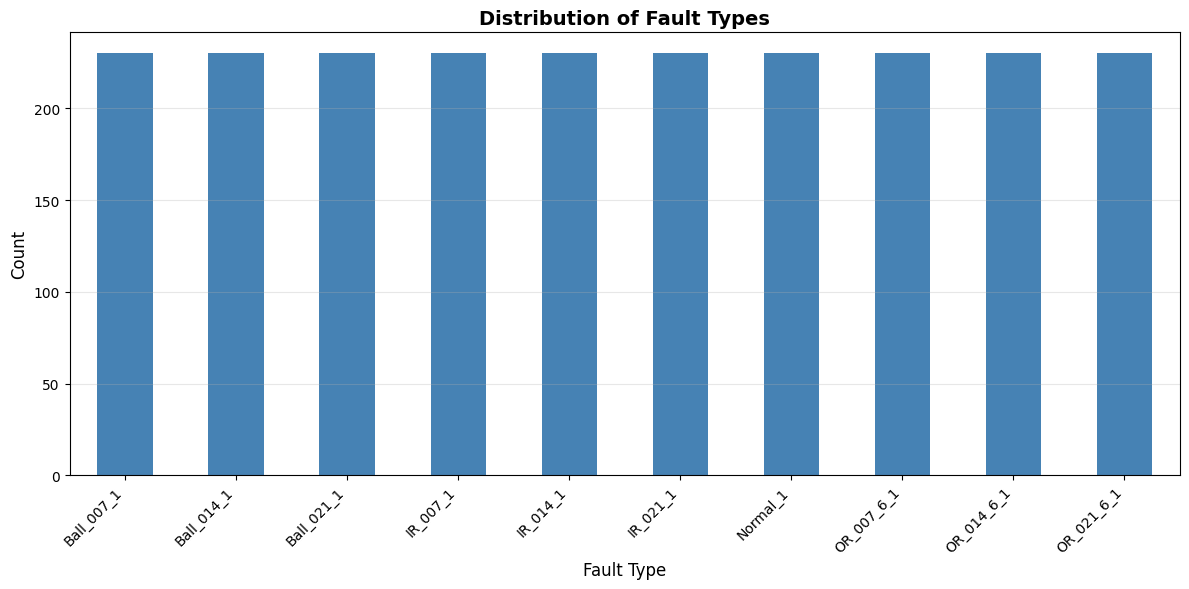

In [4]:
# Class distribution
fault_counts = data_time['fault'].value_counts().sort_index()
print("Fault type distribution:")
print(fault_counts)
print(f"\nTotal samples: {len(data_time)}")

plt.figure(figsize=(12, 6))
fault_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Fault Types', fontsize=14, fontweight='bold')
plt.xlabel('Fault Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretasi Chart Distribusi Kelas:**

Chart di atas menunjukkan distribusi sampel untuk setiap jenis kerusakan bearing. Hasil menunjukkan bahwa dataset **seimbang sempurna** dengan 230 sampel untuk setiap dari 10 jenis kerusakan:

- **3 jenis kerusakan Ball** (Ball_007_1, Ball_014_1, Ball_021_1) dengan tingkat keparahan berbeda
- **3 jenis kerusakan Inner Race** (IR_007_1, IR_014_1, IR_021_1) dengan tingkat keparahan berbeda  
- **3 jenis kerusakan Outer Race** (OR_007_6_1, OR_014_6_1, OR_021_6_1) dengan tingkat keparahan berbeda
- **1 kelas Normal** (Normal_1)

Keseimbangan dataset ini penting untuk pelatihan model yang adil dan menghindari bias terhadap kelas mayoritas. Dengan distribusi yang seimbang, model dapat belajar dengan baik untuk semua jenis kerusakan.


In [5]:
# Feature statistics
feature_cols = data_time.columns[:-1]  # All columns except 'fault'
print("Feature statistics:")
print(data_time[feature_cols].describe())


Feature statistics:
               max          min         mean           sd          rms  \
count  2300.000000  2300.000000  2300.000000  2300.000000  2300.000000   
mean      1.575079    -1.550994     0.015711     0.341601     0.342289   
std       1.578422     1.602706     0.006469     0.305279     0.304813   
min       0.157300    -6.292600     0.003246     0.059140     0.061067   
25%       0.456398    -2.174975     0.011236     0.135506     0.136374   
50%       0.794510    -0.733700     0.013730     0.188551     0.190662   
75%       2.278425    -0.426987     0.018638     0.555589     0.555671   
max       6.825900    -0.160220     0.038386     1.256577     1.256311   

          skewness     kurtosis        crest         form  
count  2300.000000  2300.000000  2300.000000  2300.000000  
mean     -0.042251     2.664444     4.173130    26.544769  
std       0.180774     4.411096     1.148349    29.209702  
min      -1.089928    -0.803795     2.428511     3.484429  
25%      -0.1

## Membagi Dataset menjadi Train dan Test

In [6]:
train_data, test_data = train_test_split(data_time, test_size = 750, stratify = data_time['fault'], random_state = 1234)
test_data['fault'].value_counts()

fault
OR_007_6_1    75
IR_014_1      75
OR_014_6_1    75
OR_021_6_1    75
Normal_1      75
IR_021_1      75
Ball_014_1    75
Ball_007_1    75
Ball_021_1    75
IR_007_1      75
Name: count, dtype: int64

## Penskalaan Fitur pada Set Training

In [7]:
# Scale each column to have zero mean and standard deviation equal to 1
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data.iloc[:,:-1])
pd.DataFrame(train_data_scaled).describe()

,0,1,2,3,4,5,6,7,8
count,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03
mean,1.260640e-16,1.002782e-16,-2.888012e-16,6.016693e-17,-5.386372e-17,1.833659e-17,-5.500976e-17,4.950878e-16,-2.521281e-17
std,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00
min,-8.877055e-01,-2.951564e+00,-1.935376e+00,-9.258092e-01,-9.231913e-01,-5.951422e+00,-7.874742e-01,-1.481163e+00,-7.775653e-01
25%,-7.088474e-01,-3.753614e-01,-6.908705e-01,-6.755048e-01,-6.760659e-01,-3.678525e-01,-6.073122e-01,-8.064817e-01,-6.475107e-01
50%,-4.958143e-01,5.113022e-01,-3.141526e-01,-5.055027e-01,-5.038108e-01,2.140248e-01,-4.182916e-01,-2.135605e-01,-4.548003e-01
75%,4.477234e-01,7.003484e-01,4.560105e-01,7.015641e-01,7.003255e-01,5.823124e-01,2.860828e-01,5.648177e-01,4.360429e-01
max,3.297226e+00,8.671141e-01,3.503861e+00,2.980548e+00,2.981995e+00,4.906756e+00,6.349353e+00,4.049712e+00,9.629399e+00


In [8]:
test_data_scaled = (test_data.iloc[:,:-1].values - scaler.mean_)/np.sqrt(scaler.var_)
pd.DataFrame(test_data_scaled).describe()


,0,1,2,3,4,5,6,7,8
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,-0.013718,0.003277,-0.018151,-0.013327,-0.013375,-0.035946,0.018838,0.009379,-0.012433
std,0.976752,0.993896,1.003708,0.987301,0.987315,1.105931,1.028360,0.998996,0.936491
min,-0.895968,-2.754539,-1.590184,-0.922087,-0.922953,-6.014935,-0.759377,-1.515700,-0.772309
25%,-0.706453,-0.429163,-0.720867,-0.677965,-0.678545,-0.355683,-0.606352,-0.762882,-0.641796
50%,-0.494044,0.503185,-0.303458,-0.492809,-0.490457,0.224657,-0.415267,-0.219297,-0.452940
75%,0.394936,0.704214,0.401811,0.669274,0.667916,0.576534,0.294171,0.547845,0.447909
max,3.008545,0.861398,3.003970,2.885914,2.887282,6.301407,5.007205,3.784107,3.531440


## Evaluasi Model
Sekarang dapatkan prediksi dari model dan buat confusion matrix serta classification report.

In [9]:
from sklearn.metrics import classification_report,confusion_matrix

Plotting confusion matrix.

- **recall**    =    untuk setiap kerusakan, proporsi yang teridentifikasi dengan benar dari total yang sebenarnya = `TP / (TP + sum(FN))`
- **precision** = untuk setiap kerusakan, proporsi yang teridentifikasi dengan benar dari total prediksi = `TP / (TP + sum(FP))`

Rujuk ke [Understanding Data Science Classification Metrics in Scikit-Learn in Python](https://towardsdatascience.com/understanding-data-science-classification-metrics-in-scikit-learn-in-python-3bc336865019) untuk penjelasan metrik ini

## Tuning Hyperparameter untuk Optimasi Model

Kita akan memeriksa grid parameter untuk menemukan yang terbaik. Untuk setiap kombinasi parameter, dilakukan 10 fold cross-validation.
- Pahami apa itu [10 fold cross-validation](https://machinelearningmastery.com/k-fold-cross-validation/)

In [13]:
parameters = {"C":[1, 10, 45, 47,49, 50, 51, 55, 100, 300, 500],
             'gamma':[0.01, 0.05, 0.1, 0.5, 1, 5],
             'kernel':["rbf"]}

## Melatih Model Tree-Based

Kita akan melatih tiga model berbasis pohon: Decision Tree, Random Forest, dan XGBoost. Model-model ini tidak memerlukan feature scaling, jadi kita akan menggunakan data yang tidak di-scale.


In [19]:
# Prepare unscaled data for tree models (tree models don't require scaling)
X_train_unscaled = train_data.iloc[:, :-1].values
X_test_unscaled = test_data.iloc[:, :-1].values

# Encode string labels to numeric values (required for XGBoost and for consistency)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(train_data['fault'].values)
y_test = le.transform(test_data['fault'].values)

# Store the label encoder for later use (e.g., for confusion matrix labels)
fault_type_encoded = le.classes_

print(f"Training data shape: {X_train_unscaled.shape}")
print(f"Test data shape: {X_test_unscaled.shape}")
print(f"Number of classes: {len(le.classes_)}")
print(f"Class labels: {le.classes_}")


Training data shape: (1550, 9)
Test data shape: (750, 9)
Number of classes: 10
Class labels: ['Ball_007_1' 'Ball_014_1' 'Ball_021_1' 'IR_007_1' 'IR_014_1' 'IR_021_1'
 'Normal_1' 'OR_007_6_1' 'OR_014_6_1' 'OR_021_6_1']


### Training Decision Tree Model


In [20]:
# Decision Tree hyperparameter tuning
dt_params = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Training Decision Tree with GridSearchCV...")
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=10, n_jobs=-1, scoring='accuracy')
dt_grid.fit(X_train_unscaled, y_train)

best_dt = dt_grid.best_estimator_
print(f"Best Decision Tree parameters: {dt_grid.best_params_}")
print(f"Best Decision Tree CV score: {dt_grid.best_score_:.4f}")


Training Decision Tree with GridSearchCV...
Best Decision Tree parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Decision Tree CV score: 0.9516


### Training Random Forest Model


In [21]:
# Random Forest hyperparameter tuning
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("Training Random Forest with GridSearchCV...")
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=10, n_jobs=-1, scoring='accuracy')
rf_grid.fit(X_train_unscaled, y_train)

best_rf = rf_grid.best_estimator_
print(f"Best Random Forest parameters: {rf_grid.best_params_}")
print(f"Best Random Forest CV score: {rf_grid.best_score_:.4f}")


Training Random Forest with GridSearchCV...
Best Random Forest parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
Best Random Forest CV score: 0.9619


### Training XGBoost Model


In [22]:
# XGBoost hyperparameter tuning
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

print("Training XGBoost with GridSearchCV...")
xgb_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'), 
                        xgb_params, cv=10, n_jobs=-1, scoring='accuracy')
xgb_grid.fit(X_train_unscaled, y_train)

best_xgb = xgb_grid.best_estimator_
print(f"Best XGBoost parameters: {xgb_grid.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid.best_score_:.4f}")


Training XGBoost with GridSearchCV...
Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best XGBoost CV score: 0.9587


### Inisialisasi SHAP Explainer dan Perhitungan SHAP Values

Kita akan menggunakan TreeExplainer untuk menghitung SHAP values dari ketiga model. TreeExplainer sangat efisien untuk model berbasis pohon.


In [23]:
# Ensure fault_type is defined for later use (using original string labels)
if 'fault_type' not in globals():
    fault_type = np.array(sorted(data_time['fault'].unique()))
else:
    # Use the label encoder classes to ensure consistency
    fault_type = le.classes_

# Prepare a sample of test data for SHAP analysis (200 samples for efficiency)
test_sample_size = min(200, len(X_test_unscaled))
test_sample_indices = np.random.choice(len(X_test_unscaled), test_sample_size, replace=False)
test_sample_shap = X_test_unscaled[test_sample_indices]

print(f"Using {test_sample_size} samples for SHAP analysis")
print(f"Test sample shape: {test_sample_shap.shape}")

# Initialize SHAP TreeExplainer for each model
print("\nInitializing SHAP TreeExplainer for Decision Tree...")
explainer_dt = shap.TreeExplainer(best_dt)
shap_values_dt = explainer_dt.shap_values(test_sample_shap)

print("Initializing SHAP TreeExplainer for Random Forest...")
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(test_sample_shap)

print("Initializing SHAP TreeExplainer for XGBoost...")
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(test_sample_shap)

print("\nSHAP values calculated successfully!")
if isinstance(shap_values_dt, list):
    print(f"Decision Tree SHAP shape: {[sv.shape for sv in shap_values_dt]}")
else:
    print(f"Decision Tree SHAP shape: {shap_values_dt.shape}")
if isinstance(shap_values_rf, list):
    print(f"Random Forest SHAP shape: {[sv.shape for sv in shap_values_rf]}")
else:
    print(f"Random Forest SHAP shape: {shap_values_rf.shape}")
if isinstance(shap_values_xgb, list):
    print(f"XGBoost SHAP shape: {[sv.shape for sv in shap_values_xgb]}")
else:
    print(f"XGBoost SHAP shape: {shap_values_xgb.shape}")


Using 200 samples for SHAP analysis
Test sample shape: (200, 9)

Initializing SHAP TreeExplainer for Decision Tree...
Initializing SHAP TreeExplainer for Random Forest...
Initializing SHAP TreeExplainer for XGBoost...

SHAP values calculated successfully!
Decision Tree SHAP shape: (200, 9, 10)
Random Forest SHAP shape: (200, 9, 10)
XGBoost SHAP shape: (200, 9, 10)


## Analisis Eksplainabilitas SHAP

SHAP (SHapley Additive exPlanations) adalah pendekatan terpadu untuk menjelaskan output dari model machine learning apa pun. Ini menghubungkan alokasi kredit optimal dengan penjelasan lokal menggunakan nilai Shapley klasik dari teori permainan dan ekstensi terkaitnya.

### Memahami Nilai SHAP

- **Nilai SHAP** menunjukkan seberapa besar kontribusi setiap fitur terhadap prediksi untuk instance tertentu
- **Nilai SHAP positif** mendorong prediksi lebih tinggi (menuju kelas tertentu)
- **Nilai SHAP negatif** mendorong prediksi lebih rendah (menjauhi kelas tertentu)
- **Kepentingan fitur** diukur dengan rata-rata nilai SHAP absolut di semua instance


**Catatan tentang Pemilihan Sampel SHAP**: 

Untuk efisiensi komputasi, perhitungan nilai SHAP dilakukan pada subset 200 sampel dari set test (bukan seluruh 750 sampel). Alasan penggunaan 200 sampel:

- **Efisiensi TreeExplainer**: Meskipun TreeExplainer sangat efisien untuk model berbasis pohon, menggunakan subset 200 sampel tetap mempercepat analisis tanpa kehilangan temuan penting.
- **Representasi Statistik**: 200 sampel (26,7% dari test set) dengan stratified sampling memberikan representasi proporsional yang cukup untuk analisis eksplainabilitas.
- **Konsistensi**: Menggunakan jumlah sampel yang sama memungkinkan perbandingan yang adil antara ketiga model tree-based.

Set test lengkap (750 sampel) tetap digunakan untuk evaluasi model final dan semua metrik performa (confusion matrix, ROC-AUC, PR-AUC).


### Analisis SHAP untuk Model Tree-Based

Kita akan menggunakan SHAP untuk menjelaskan prediksi dari ketiga model tree-based (Decision Tree, Random Forest, dan XGBoost). Karena semua model ini berbasis pohon, kita akan menggunakan TreeExplainer yang sangat efisien dan akurat.


### Analisis Kepentingan Fitur Global

Kepentingan fitur global menunjukkan fitur mana yang paling penting di semua prediksi untuk setiap model tree-based.


**Interpretasi Chart Feature Importance - Stacked Bar:**

Chart di bawah menunjukkan kepentingan fitur global untuk setiap model tree-based dengan breakdown per-class menggunakan stacked horizontal bar chart. Setiap warna mewakili kontribusi dari kelas yang berbeda.

**Cara Membaca Chart:**
- **Panjang total bar**: Total kepentingan fitur di semua kelas
- **Segmen berwarna**: Kontribusi dari setiap kelas individual (Class 0-9)
- **Urutan fitur**: Diurutkan dari total kepentingan terendah (bawah) ke tertinggi (atas)

**Temuan:**
- **Fitur Most Important Overall**: Fitur di bagian atas chart memiliki total kepentingan tertinggi
- **Variabilitas Per-Class**: Warna yang beragam menunjukkan bahwa model menggunakan fitur yang berbeda untuk kelas yang berbeda
- **Perbandingan Model**: Membandingkan fitur penting antara Decision Tree, Random Forest, dan XGBoost


Decision Tree Feature Importance

Top Features by Total Importance (Decision Tree):
skewness    0.001632
crest       0.007659
max         0.008753
sd          0.056064
form        0.140372
kurtosis    0.379852
min         0.535449
mean        0.600077
rms         1.026253
dtype: float64


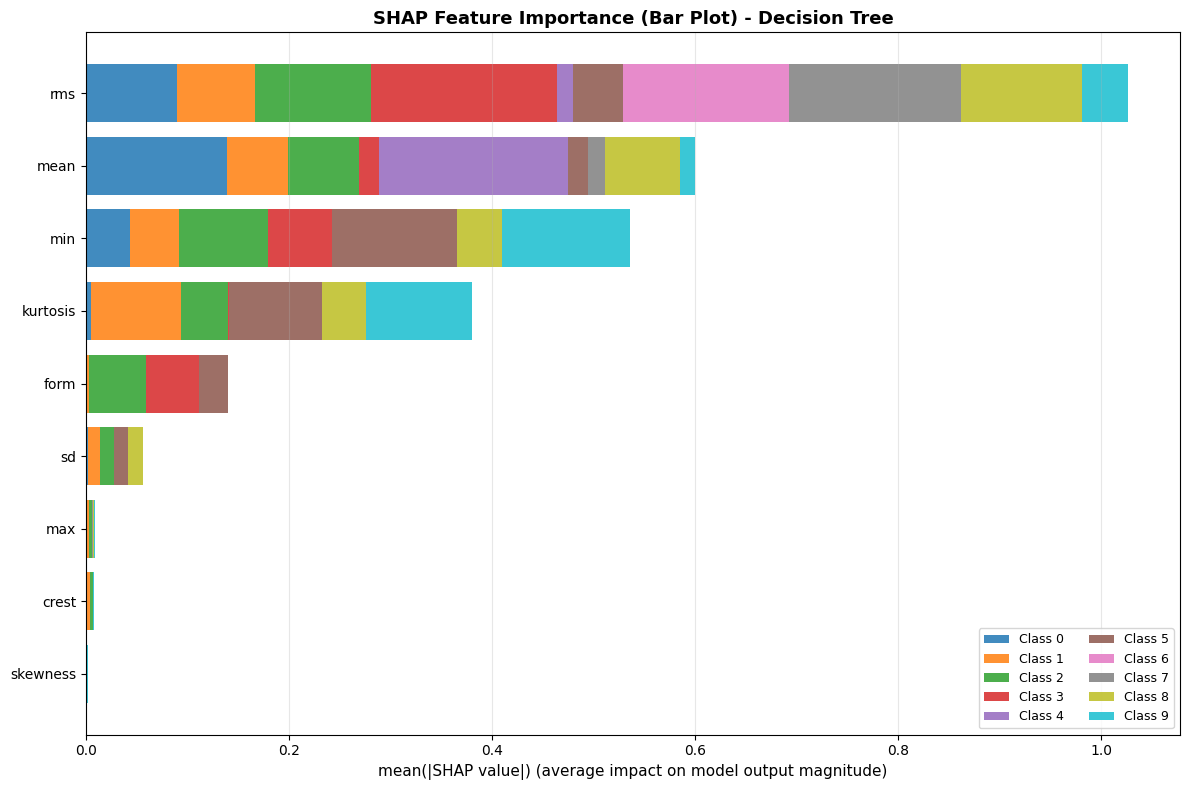


Random Forest Feature Importance

Top Features by Total Importance (Random Forest):
skewness    0.026903
crest       0.122806
max         0.174990
form        0.227251
kurtosis    0.288928
min         0.297960
rms         0.369676
sd          0.440642
mean        0.445975
dtype: float64


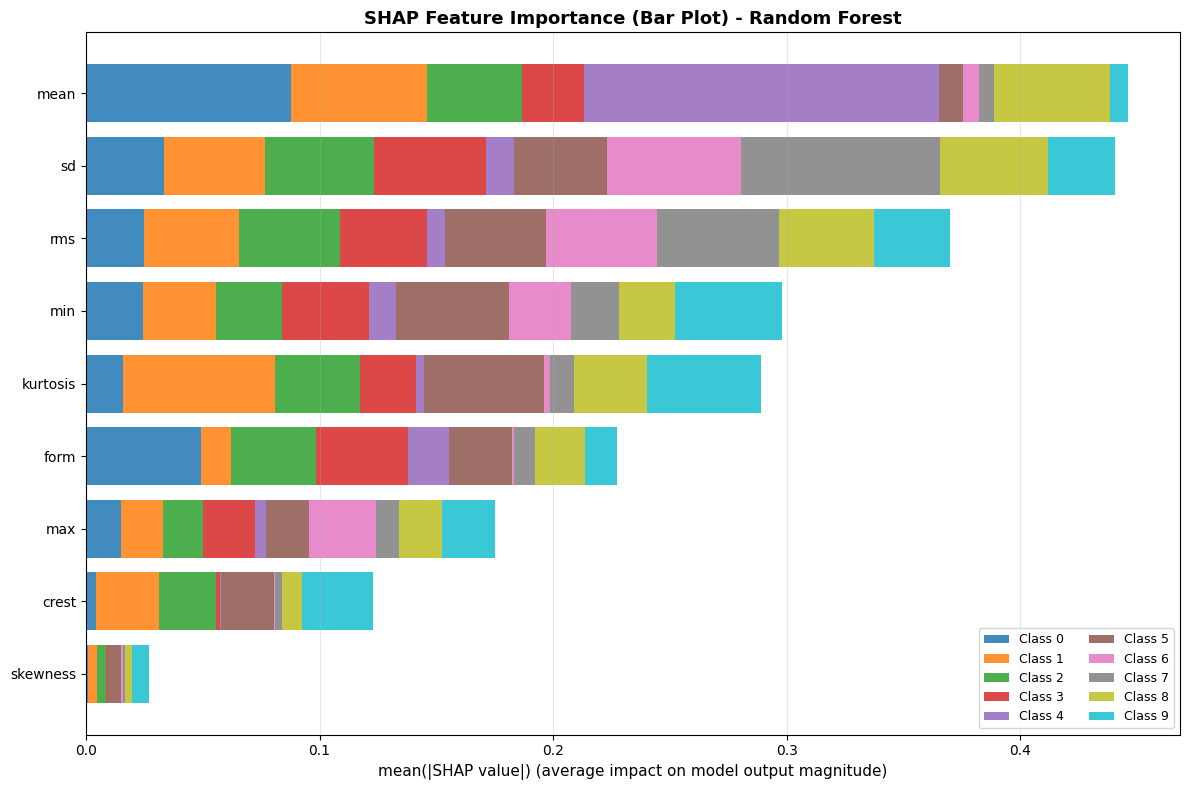


XGBoost Feature Importance

Top Features by Total Importance (XGBoost):
crest       1.237735
rms         1.345498
skewness    1.466607
min         2.406481
max         4.211552
form        6.397583
kurtosis    7.706687
mean        8.530369
sd          9.660676
dtype: float32


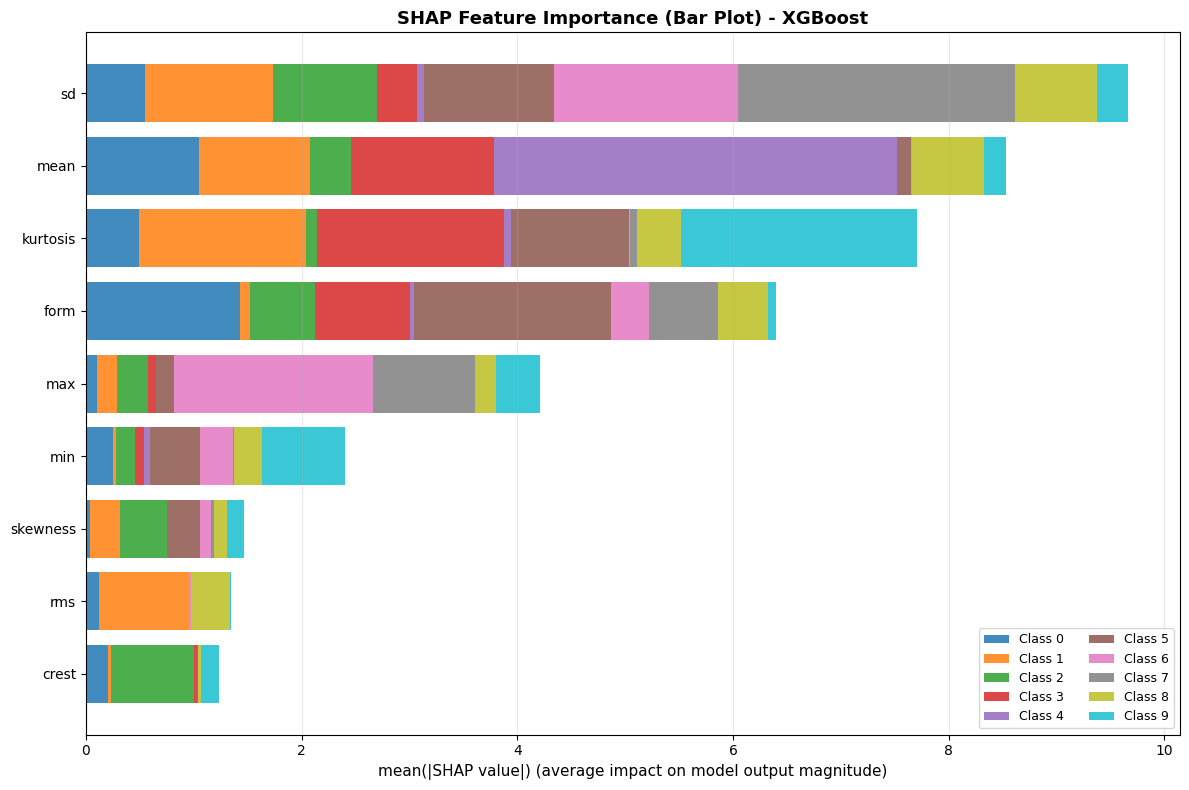

In [24]:
# Helper function to process SHAP values and create feature importance visualization
def process_shap_values(shap_values, model_name, feature_names, fault_type):
    """Process SHAP values and create feature importance visualization"""
    
    # Handle different SHAP value structures
    if isinstance(shap_values, list):
        # List of arrays, one per class
        n_classes = len(shap_values)
        n_features = shap_values[0].shape[1]
        n_samples = shap_values[0].shape[0]
        
        # Convert to 3D array: (n_samples, n_features, n_classes)
        shap_array = np.zeros((n_samples, n_features, n_classes))
        for i, sv in enumerate(shap_values):
            shap_array[:, :, i] = sv
        shap_values = shap_array
    
    # Ensure it's 3D: (n_samples, n_features, n_classes)
    if len(shap_values.shape) == 2:
        # Binary classification or single output
        shap_values = shap_values[:, :, np.newaxis]
    
    n_samples, n_features, n_classes = shap_values.shape
    
    # Calculate mean |SHAP value| per feature per class (average over samples)
    class_importance = np.abs(shap_values).mean(axis=0)  # Shape: (n_features, n_classes)
    
    # Create DataFrame for per-class importance
    per_class_df = pd.DataFrame(class_importance, 
                                 index=feature_names[:n_features],
                                 columns=[f'Class {i}' for i in range(n_classes)])
    
    # Sort by total importance (sum across all classes)
    per_class_df['Total'] = per_class_df.sum(axis=1)
    per_class_df = per_class_df.sort_values('Total', ascending=True)
    per_class_df = per_class_df.drop('Total', axis=1)
    
    print(f"\nTop Features by Total Importance ({model_name}):")
    print(per_class_df.sum(axis=1).tail(10))
    
    # Create stacked horizontal bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Colors for each class - using tab10 colormap
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    
    # Plot stacked bars
    left = np.zeros(len(per_class_df))
    for i, class_col in enumerate(per_class_df.columns):
        ax.barh(range(len(per_class_df)), per_class_df[class_col], 
                left=left, label=class_col, color=colors[i], alpha=0.85)
        left += per_class_df[class_col].values
    
    ax.set_yticks(range(len(per_class_df)))
    ax.set_yticklabels(per_class_df.index)
    ax.set_xlabel('mean(|SHAP value|) (average impact on model output magnitude)', fontsize=11)
    ax.set_title(f'SHAP Feature Importance (Bar Plot) - {model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9, ncol=2)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Store overall importance
    mean_abs_shap = per_class_df.sum(axis=1).values
    feature_importance_df = pd.DataFrame({
        'Feature': per_class_df.index,
        'Mean |SHAP Value|': mean_abs_shap
    })
    
    return feature_importance_df, shap_values

# Get feature names and fault types
feature_names = data_time.columns[:-1].tolist()
if 'fault_type' not in globals():
    fault_type = np.array(sorted(data_time['fault'].unique()))

# Process SHAP values for Decision Tree
print("="*70)
print("Decision Tree Feature Importance")
print("="*70)
feature_importance_dt, shap_values_dt_processed = process_shap_values(
    shap_values_dt, "Decision Tree", feature_names, fault_type
)

# Process SHAP values for Random Forest
print("\n" + "="*70)
print("Random Forest Feature Importance")
print("="*70)
feature_importance_rf, shap_values_rf_processed = process_shap_values(
    shap_values_rf, "Random Forest", feature_names, fault_type
)

# Process SHAP values for XGBoost
print("\n" + "="*70)
print("XGBoost Feature Importance")
print("="*70)
feature_importance_xgb, shap_values_xgb_processed = process_shap_values(
    shap_values_xgb, "XGBoost", feature_names, fault_type
)


**Interpretasi SHAP Summary Plot:**

SHAP Summary Plot menunjukkan distribusi kontribusi setiap fitur terhadap prediksi untuk kelas yang dipilih. Plot ini menggabungkan informasi dari semua 200 sampel dalam subset SHAP.

**Cara Membaca Plot:**
- **Sumbu Y**: Fitur diurutkan berdasarkan kepentingan (dari atas ke bawah)
- **Sumbu X**: Nilai SHAP (kontribusi fitur terhadap prediksi)
- **Warna**: Nilai fitur aktual (merah = tinggi, biru = rendah)
- **Posisi Horizontal**: Nilai SHAP positif (kanan) mendorong prediksi ke kelas ini, negatif (kiri) menjauhkan

**Temuan:**
- Fitur dengan spread SHAP values yang lebar menunjukkan variabilitas kontribusi yang tinggi
- Pola warna menunjukkan hubungan antara nilai fitur dan kontribusinya
- Plot ini membantu memahami bagaimana setiap model tree-based menggunakan fitur secara global untuk kelas tertentu


### SHAP Summary Plots untuk Setiap Model

Kita akan menampilkan SHAP summary plots untuk setiap model tree-based untuk melihat distribusi kontribusi fitur.


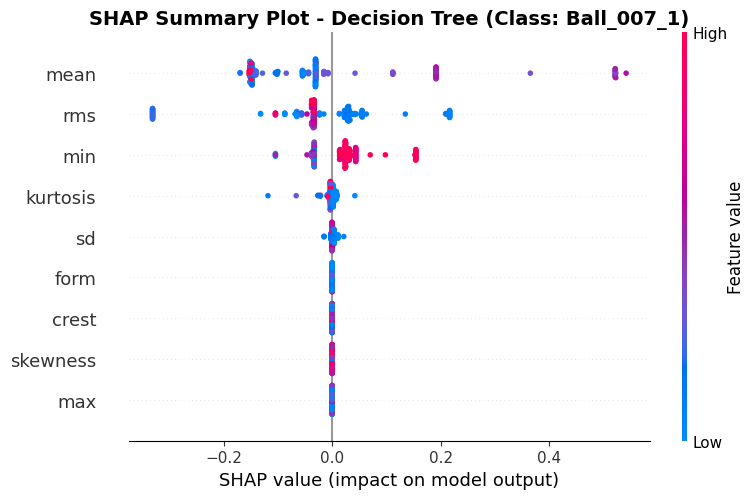

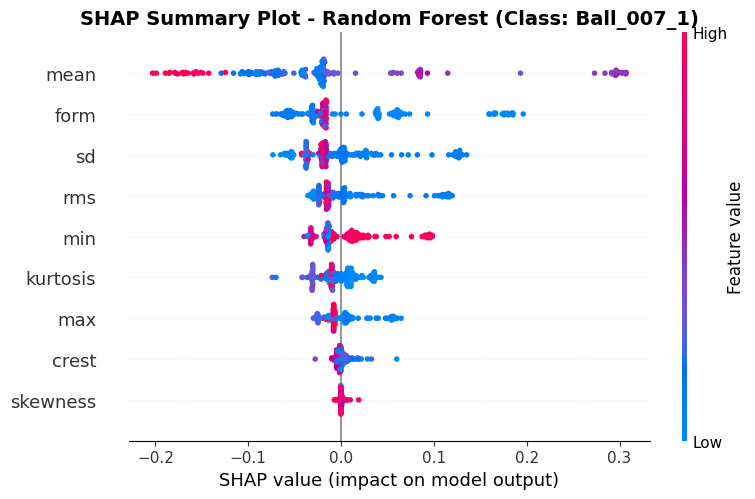

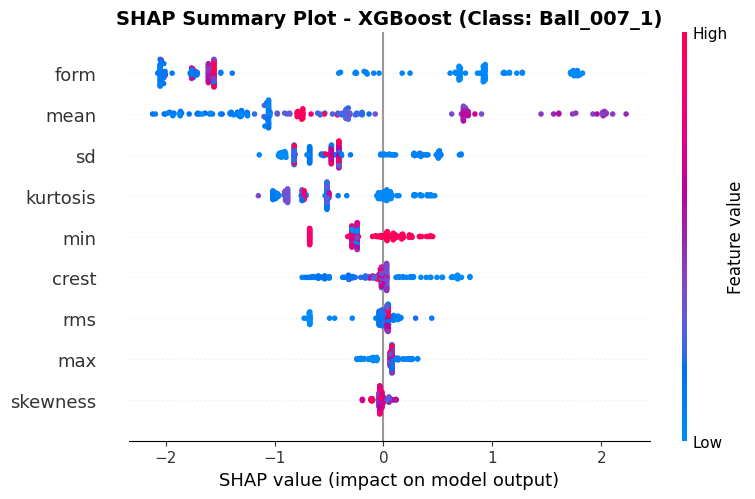

In [25]:
# SHAP Summary Plots for all three models
# Using the first class as example (can be modified for other classes)
class_idx = 0

# Get feature names
feature_names = data_time.columns[:-1].tolist()

# Decision Tree Summary Plot
if len(shap_values_dt_processed.shape) == 3:
    shap_values_dt_class = shap_values_dt_processed[:, :, class_idx]
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_dt_class, test_sample_shap, feature_names=feature_names, show=False)
    plt.title(f'SHAP Summary Plot - Decision Tree (Class: {fault_type[class_idx]})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Random Forest Summary Plot
if len(shap_values_rf_processed.shape) == 3:
    shap_values_rf_class = shap_values_rf_processed[:, :, class_idx]
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_rf_class, test_sample_shap, feature_names=feature_names, show=False)
    plt.title(f'SHAP Summary Plot - Random Forest (Class: {fault_type[class_idx]})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# XGBoost Summary Plot
if len(shap_values_xgb_processed.shape) == 3:
    shap_values_xgb_class = shap_values_xgb_processed[:, :, class_idx]
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_xgb_class, test_sample_shap, feature_names=feature_names, show=False)
    plt.title(f'SHAP Summary Plot - XGBoost (Class: {fault_type[class_idx]})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Evaluasi Model Komprehensif

Setelah melatih ketiga model, kita akan melakukan evaluasi komprehensif dengan berbagai metrik untuk membandingkan performa mereka.


### Prediksi dan Akurasi Model

Mari kita hitung prediksi dan akurasi untuk ketiga model pada training dan test set.


In [27]:
# Generate predictions for all three models
print("Generating predictions for all models...")

# Decision Tree predictions
dt_train_pred = best_dt.predict(X_train_unscaled)
dt_test_pred = best_dt.predict(X_test_unscaled)

# Random Forest predictions
rf_train_pred = best_rf.predict(X_train_unscaled)
rf_test_pred = best_rf.predict(X_test_unscaled)

# XGBoost predictions
xgb_train_pred = best_xgb.predict(X_train_unscaled)
xgb_test_pred = best_xgb.predict(X_test_unscaled)

# Calculate accuracy scores
from sklearn.metrics import accuracy_score

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

xgb_train_acc = accuracy_score(y_train, xgb_train_pred)
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)

# Print accuracy results
print("\n" + "="*70)
print("MODEL ACCURACY COMPARISON")
print("="*70)
print(f"\nDecision Tree:")
print(f"  Training Accuracy: {dt_train_acc:.4f} ({int(dt_train_acc * len(y_train))}/{len(y_train)} correct)")
print(f"  Test Accuracy:     {dt_test_acc:.4f} ({int(dt_test_acc * len(y_test))}/{len(y_test)} correct)")

print(f"\nRandom Forest:")
print(f"  Training Accuracy: {rf_train_acc:.4f} ({int(rf_train_acc * len(y_train))}/{len(y_train)} correct)")
print(f"  Test Accuracy:     {rf_test_acc:.4f} ({int(rf_test_acc * len(y_test))}/{len(y_test)} correct)")

print(f"\nXGBoost:")
print(f"  Training Accuracy: {xgb_train_acc:.4f} ({int(xgb_train_acc * len(y_train))}/{len(y_train)} correct)")
print(f"  Test Accuracy:     {xgb_test_acc:.4f} ({int(xgb_test_acc * len(y_test))}/{len(y_test)} correct)")

print("\n" + "="*70)


Generating predictions for all models...

MODEL ACCURACY COMPARISON

Decision Tree:
  Training Accuracy: 0.9761 (1513/1550 correct)
  Test Accuracy:     0.9413 (706/750 correct)

Random Forest:
  Training Accuracy: 1.0000 (1550/1550 correct)
  Test Accuracy:     0.9573 (718/750 correct)

XGBoost:
  Training Accuracy: 0.9974 (1546/1550 correct)
  Test Accuracy:     0.9587 (719/750 correct)



### Confusion Matrices untuk Semua Model

Confusion matrix menunjukkan detail prediksi untuk setiap kelas kerusakan.


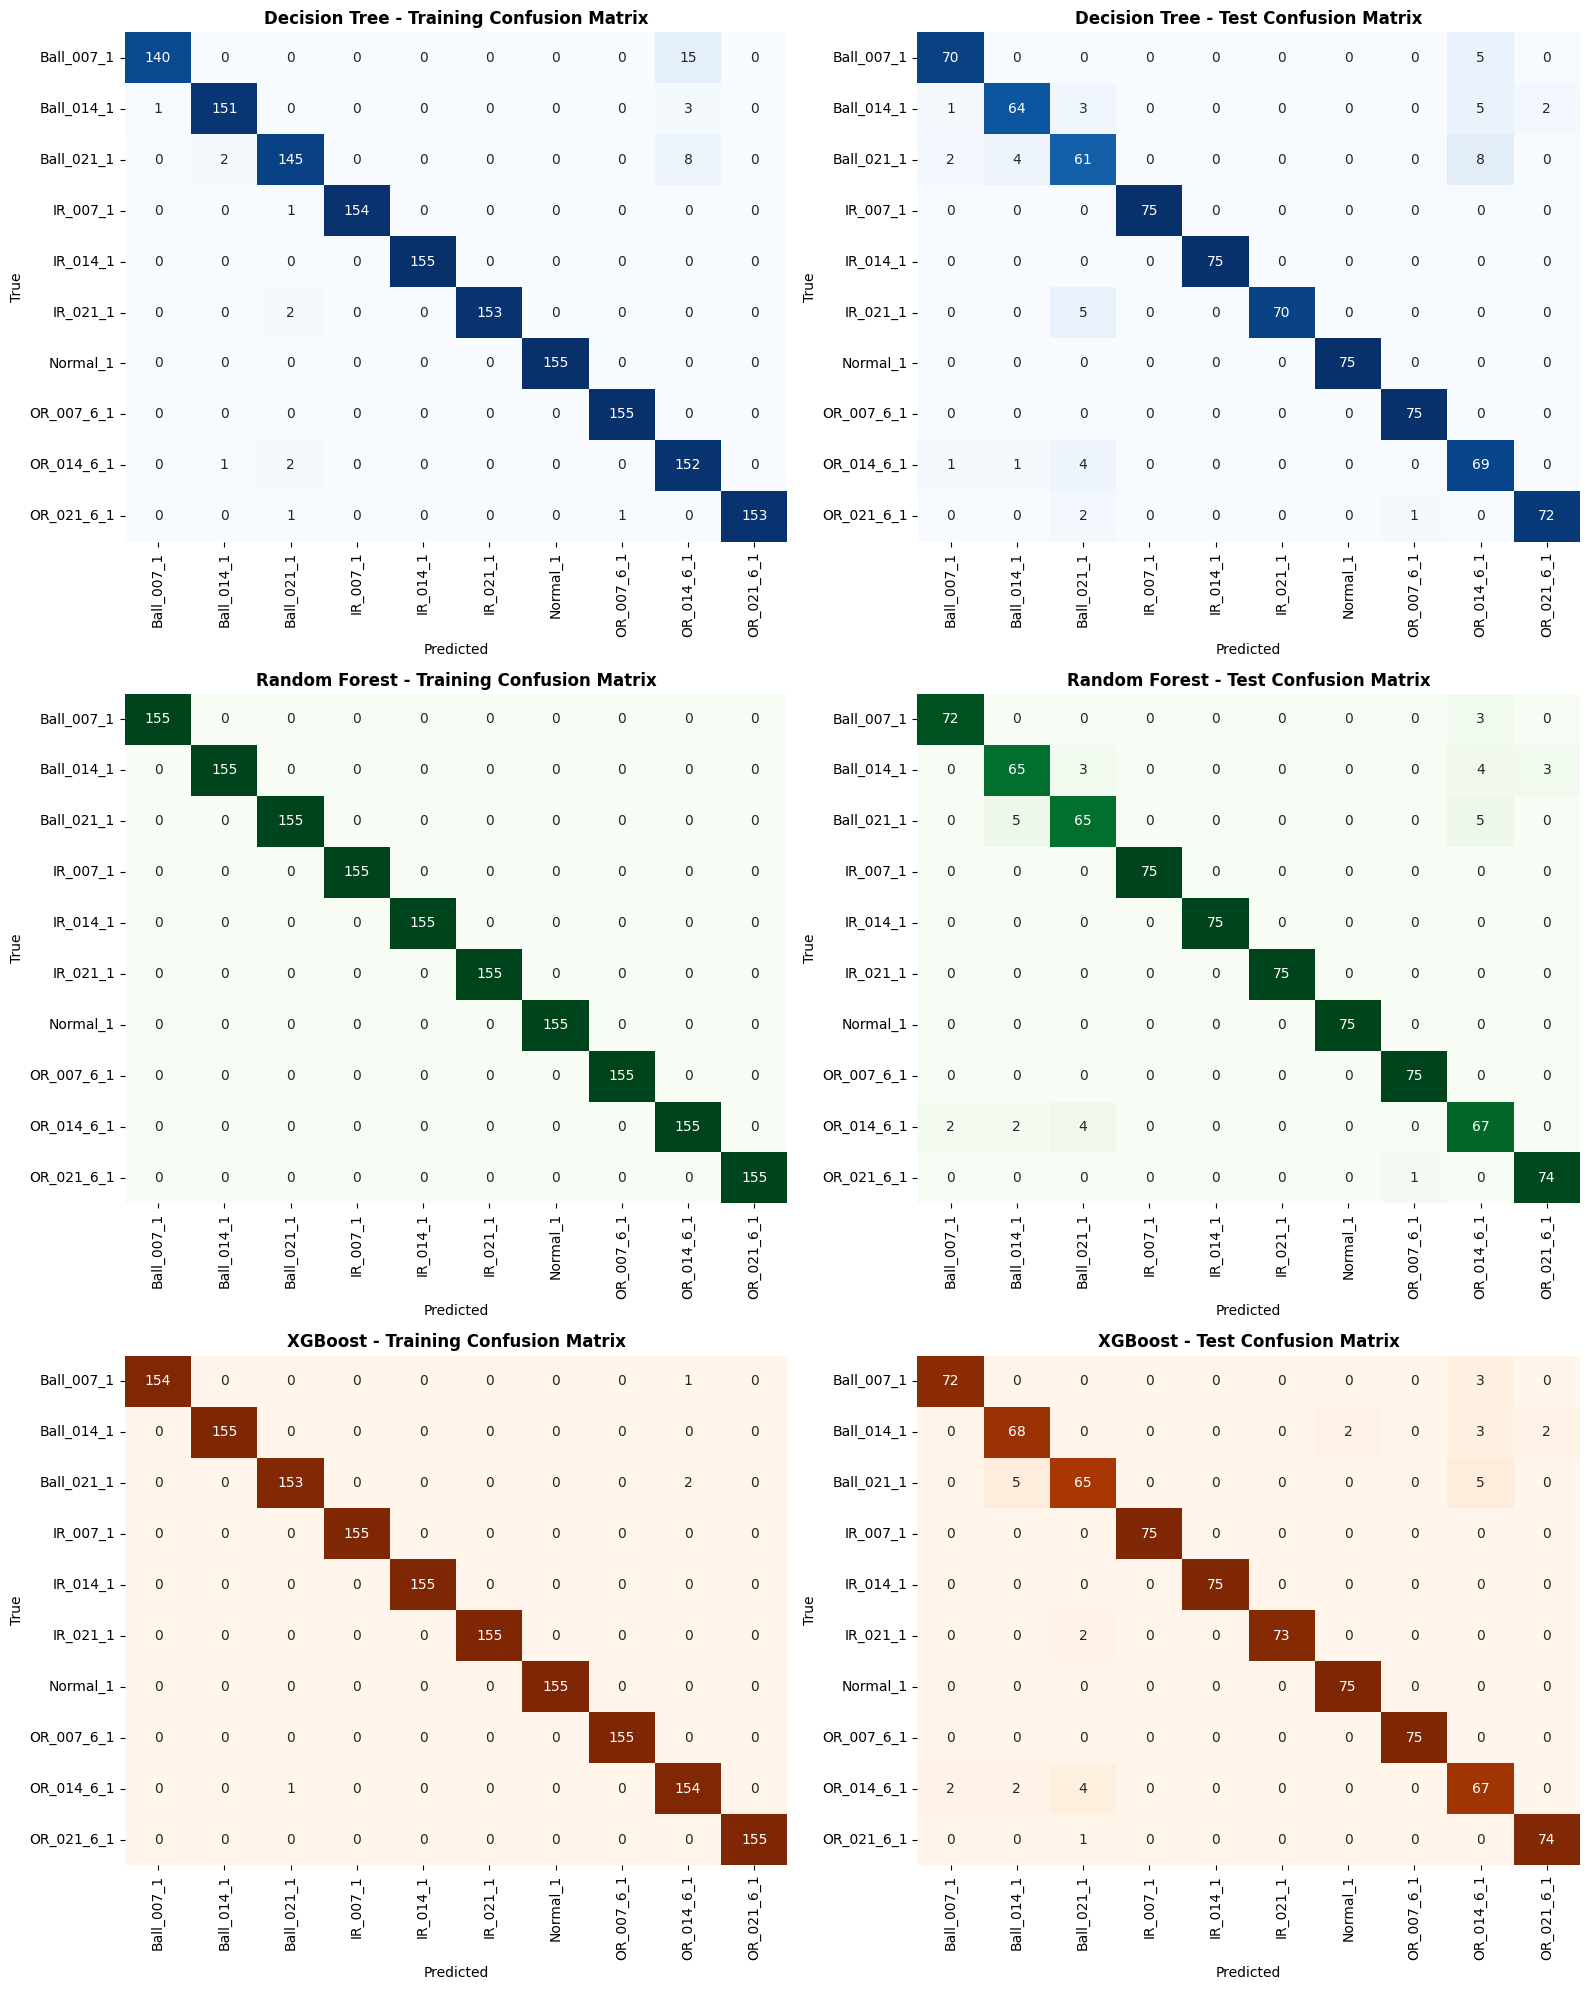


MISCLASSIFICATION SUMMARY

Decision Tree Test Set:
  Misclassifications: 44 out of 750

Random Forest Test Set:
  Misclassifications: 32 out of 750

XGBoost Test Set:
  Misclassifications: 31 out of 750


In [28]:
# Calculate confusion matrices for all models
dt_train_cm = confusion_matrix(y_train, dt_train_pred)
dt_test_cm = confusion_matrix(y_test, dt_test_pred)

rf_train_cm = confusion_matrix(y_train, rf_train_pred)
rf_test_cm = confusion_matrix(y_test, rf_test_pred)

xgb_train_cm = confusion_matrix(y_train, xgb_train_pred)
xgb_test_cm = confusion_matrix(y_test, xgb_test_pred)

# Visualize confusion matrices
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# Decision Tree
sns.heatmap(dt_train_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0], 
            xticklabels=fault_type, yticklabels=fault_type, cbar=False)
axes[0, 0].set_title('Decision Tree - Training Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted', fontsize=10)
axes[0, 0].set_ylabel('True', fontsize=10)

sns.heatmap(dt_test_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 1],
            xticklabels=fault_type, yticklabels=fault_type, cbar=False)
axes[0, 1].set_title('Decision Tree - Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontsize=10)
axes[0, 1].set_ylabel('True', fontsize=10)

# Random Forest
sns.heatmap(rf_train_cm, annot=True, fmt="d", cmap="Greens", ax=axes[1, 0],
            xticklabels=fault_type, yticklabels=fault_type, cbar=False)
axes[1, 0].set_title('Random Forest - Training Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted', fontsize=10)
axes[1, 0].set_ylabel('True', fontsize=10)

sns.heatmap(rf_test_cm, annot=True, fmt="d", cmap="Greens", ax=axes[1, 1],
            xticklabels=fault_type, yticklabels=fault_type, cbar=False)
axes[1, 1].set_title('Random Forest - Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicted', fontsize=10)
axes[1, 1].set_ylabel('True', fontsize=10)

# XGBoost
sns.heatmap(xgb_train_cm, annot=True, fmt="d", cmap="Oranges", ax=axes[2, 0],
            xticklabels=fault_type, yticklabels=fault_type, cbar=False)
axes[2, 0].set_title('XGBoost - Training Confusion Matrix', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Predicted', fontsize=10)
axes[2, 0].set_ylabel('True', fontsize=10)

sns.heatmap(xgb_test_cm, annot=True, fmt="d", cmap="Oranges", ax=axes[2, 1],
            xticklabels=fault_type, yticklabels=fault_type, cbar=False)
axes[2, 1].set_title('XGBoost - Test Confusion Matrix', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Predicted', fontsize=10)
axes[2, 1].set_ylabel('True', fontsize=10)

plt.tight_layout()
plt.show()

# Print misclassification counts
print("\n" + "="*70)
print("MISCLASSIFICATION SUMMARY")
print("="*70)
print(f"\nDecision Tree Test Set:")
print(f"  Misclassifications: {len(y_test) - int(dt_test_acc * len(y_test))} out of {len(y_test)}")

print(f"\nRandom Forest Test Set:")
print(f"  Misclassifications: {len(y_test) - int(rf_test_acc * len(y_test))} out of {len(y_test)}")

print(f"\nXGBoost Test Set:")
print(f"  Misclassifications: {len(y_test) - int(xgb_test_acc * len(y_test))} out of {len(y_test)}")
print("="*70)


### Classification Reports Detail

Classification report memberikan metrik detail untuk setiap kelas: precision, recall, dan F1-score.


In [29]:
# Generate classification reports
print("="*70)
print("DECISION TREE - CLASSIFICATION REPORT")
print("="*70)
dt_report = classification_report(y_test, dt_test_pred, target_names=fault_type, digits=4)
print(dt_report)

print("\n" + "="*70)
print("RANDOM FOREST - CLASSIFICATION REPORT")
print("="*70)
rf_report = classification_report(y_test, rf_test_pred, target_names=fault_type, digits=4)
print(rf_report)

print("\n" + "="*70)
print("XGBOOST - CLASSIFICATION REPORT")
print("="*70)
xgb_report = classification_report(y_test, xgb_test_pred, target_names=fault_type, digits=4)
print(xgb_report)


DECISION TREE - CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Ball_007_1     0.9459    0.9333    0.9396        75
  Ball_014_1     0.9275    0.8533    0.8889        75
  Ball_021_1     0.8133    0.8133    0.8133        75
    IR_007_1     1.0000    1.0000    1.0000        75
    IR_014_1     1.0000    1.0000    1.0000        75
    IR_021_1     1.0000    0.9333    0.9655        75
    Normal_1     1.0000    1.0000    1.0000        75
  OR_007_6_1     0.9868    1.0000    0.9934        75
  OR_014_6_1     0.7931    0.9200    0.8519        75
  OR_021_6_1     0.9730    0.9600    0.9664        75

    accuracy                         0.9413       750
   macro avg     0.9440    0.9413    0.9419       750
weighted avg     0.9440    0.9413    0.9419       750


RANDOM FOREST - CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Ball_007_1     0.9730    0.9600    0.9664        75
  Ball_014_1     0.9028    0.8667    0.8844        75
 

### ROC Curves dan AUC Scores

ROC (Receiver Operating Characteristic) curves menunjukkan trade-off antara True Positive Rate dan False Positive Rate untuk setiap kelas.


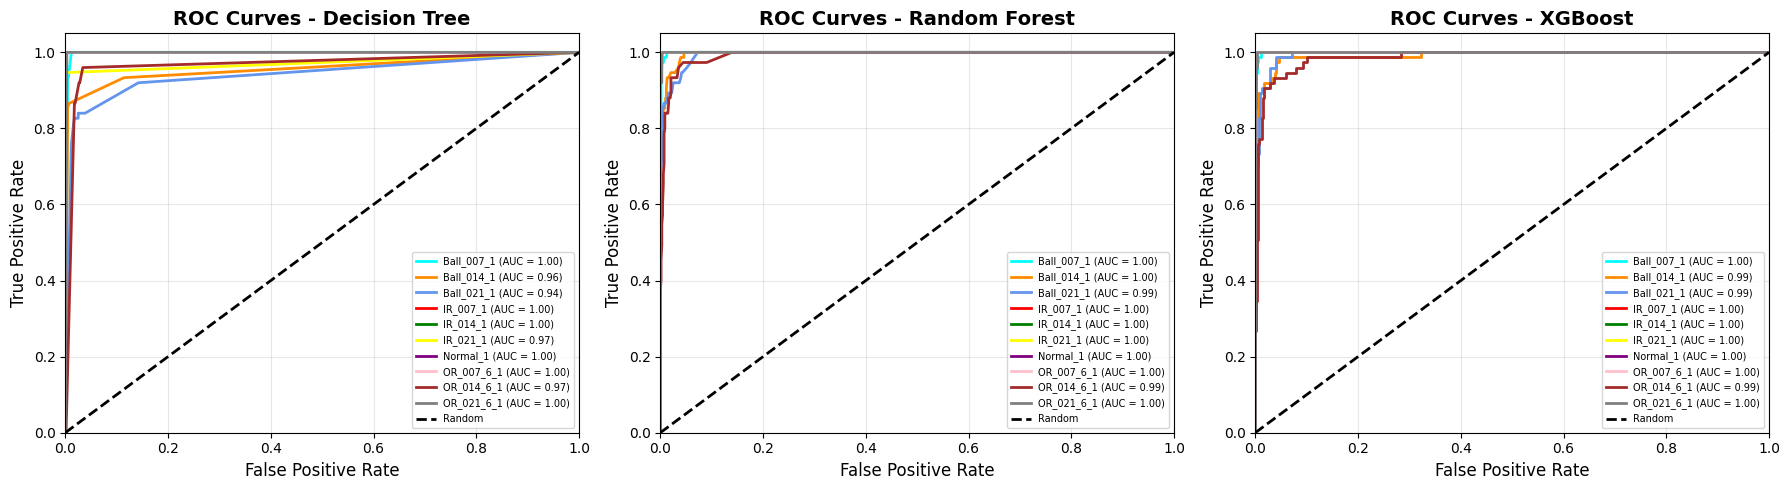


AVERAGE ROC-AUC SCORES
Decision Tree Average AUC: 0.984
Random Forest Average AUC: 0.998
XGBoost Average AUC: 0.997


In [30]:
# Get probability predictions for ROC curves
y_score_dt = best_dt.predict_proba(X_test_unscaled)
y_score_rf = best_rf.predict_proba(X_test_unscaled)
y_score_xgb = best_xgb.predict_proba(X_test_unscaled)

# Binarize the labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(fault_type)))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr_dt = dict()
tpr_dt = dict()
roc_auc_dt = dict()

fpr_rf = dict()
tpr_rf = dict()
roc_auc_rf = dict()

fpr_xgb = dict()
tpr_xgb = dict()
roc_auc_xgb = dict()

for i in range(n_classes):
    # Decision Tree
    fpr_dt[i], tpr_dt[i], _ = roc_curve(y_test_bin[:, i], y_score_dt[:, i])
    roc_auc_dt[i] = auc(fpr_dt[i], tpr_dt[i])
    
    # Random Forest
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])
    
    # XGBoost
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])

# Plot ROC curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'yellow', 'purple', 'pink', 'brown', 'gray'])

# Decision Tree ROC
ax = axes[0]
for i, color in zip(range(n_classes), colors):
    ax.plot(fpr_dt[i], tpr_dt[i], color=color, lw=2,
            label=f'{fault_type[i]} (AUC = {roc_auc_dt[i]:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Decision Tree', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=7)
ax.grid(alpha=0.3)

# Random Forest ROC
ax = axes[1]
for i, color in zip(range(n_classes), colors):
    ax.plot(fpr_rf[i], tpr_rf[i], color=color, lw=2,
            label=f'{fault_type[i]} (AUC = {roc_auc_rf[i]:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=7)
ax.grid(alpha=0.3)

# XGBoost ROC
ax = axes[2]
for i, color in zip(range(n_classes), colors):
    ax.plot(fpr_xgb[i], tpr_xgb[i], color=color, lw=2,
            label=f'{fault_type[i]} (AUC = {roc_auc_xgb[i]:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - XGBoost', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=7)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print average AUC
print("\n" + "="*70)
print("AVERAGE ROC-AUC SCORES")
print("="*70)
print(f"Decision Tree Average AUC: {np.mean(list(roc_auc_dt.values())):.3f}")
print(f"Random Forest Average AUC: {np.mean(list(roc_auc_rf.values())):.3f}")
print(f"XGBoost Average AUC: {np.mean(list(roc_auc_xgb.values())):.3f}")
print("="*70)


### Precision-Recall Curves

Precision-Recall curves menunjukkan trade-off antara precision dan recall, yang penting untuk dataset dengan kelas tidak seimbang.


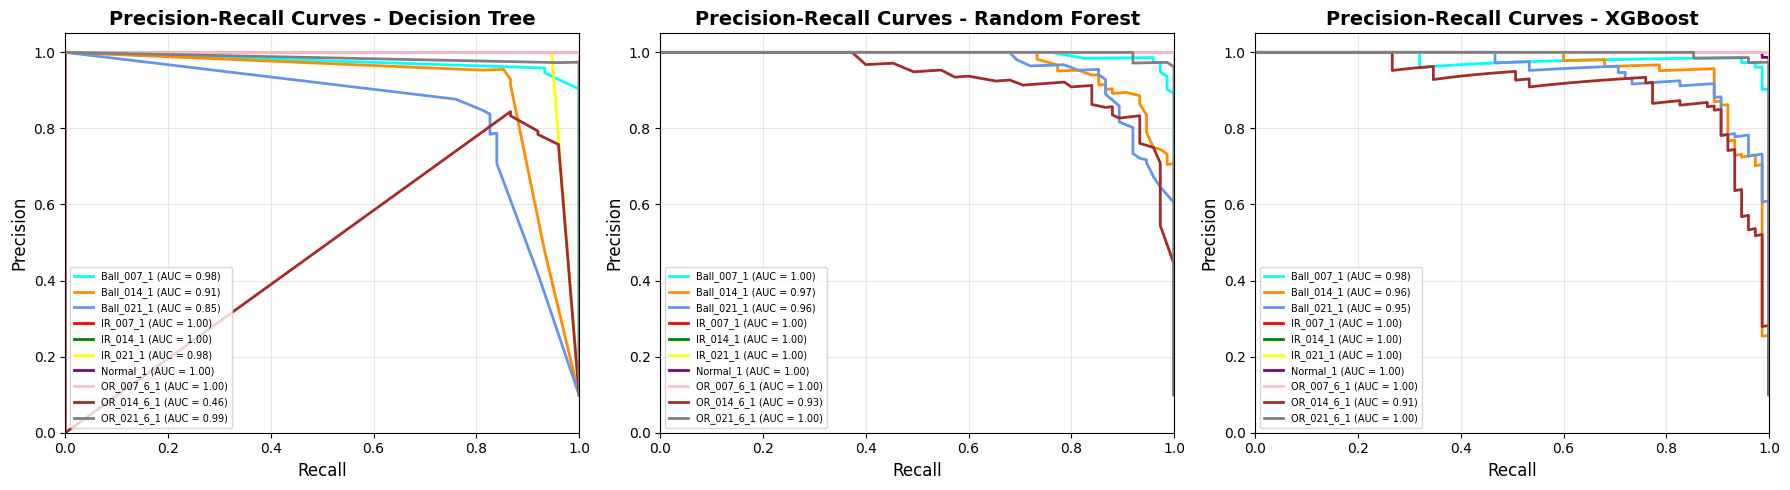


AVERAGE PRECISION-RECALL AUC SCORES
Decision Tree Average PR-AUC: 0.915
Random Forest Average PR-AUC: 0.986
XGBoost Average PR-AUC: 0.980


In [31]:
# Compute Precision-Recall curve and area for each class
precision_dt = dict()
recall_dt = dict()
pr_auc_dt = dict()

precision_rf = dict()
recall_rf = dict()
pr_auc_rf = dict()

precision_xgb = dict()
recall_xgb = dict()
pr_auc_xgb = dict()

for i in range(n_classes):
    # Decision Tree
    precision_dt[i], recall_dt[i], _ = precision_recall_curve(y_test_bin[:, i], y_score_dt[:, i])
    pr_auc_dt[i] = auc(recall_dt[i], precision_dt[i])
    
    # Random Forest
    precision_rf[i], recall_rf[i], _ = precision_recall_curve(y_test_bin[:, i], y_score_rf[:, i])
    pr_auc_rf[i] = auc(recall_rf[i], precision_rf[i])
    
    # XGBoost
    precision_xgb[i], recall_xgb[i], _ = precision_recall_curve(y_test_bin[:, i], y_score_xgb[:, i])
    pr_auc_xgb[i] = auc(recall_xgb[i], precision_xgb[i])

# Plot Precision-Recall curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'yellow', 'purple', 'pink', 'brown', 'gray'])

# Decision Tree PR
ax = axes[0]
for i, color in zip(range(n_classes), colors):
    ax.plot(recall_dt[i], precision_dt[i], color=color, lw=2,
            label=f'{fault_type[i]} (AUC = {pr_auc_dt[i]:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Decision Tree', fontsize=14, fontweight='bold')
ax.legend(loc="lower left", fontsize=7)
ax.grid(alpha=0.3)

# Random Forest PR
ax = axes[1]
for i, color in zip(range(n_classes), colors):
    ax.plot(recall_rf[i], precision_rf[i], color=color, lw=2,
            label=f'{fault_type[i]} (AUC = {pr_auc_rf[i]:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc="lower left", fontsize=7)
ax.grid(alpha=0.3)

# XGBoost PR
ax = axes[2]
for i, color in zip(range(n_classes), colors):
    ax.plot(recall_xgb[i], precision_xgb[i], color=color, lw=2,
            label=f'{fault_type[i]} (AUC = {pr_auc_xgb[i]:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - XGBoost', fontsize=14, fontweight='bold')
ax.legend(loc="lower left", fontsize=7)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print average PR-AUC
print("\n" + "="*70)
print("AVERAGE PRECISION-RECALL AUC SCORES")
print("="*70)
print(f"Decision Tree Average PR-AUC: {np.mean(list(pr_auc_dt.values())):.3f}")
print(f"Random Forest Average PR-AUC: {np.mean(list(pr_auc_rf.values())):.3f}")
print(f"XGBoost Average PR-AUC: {np.mean(list(pr_auc_xgb.values())):.3f}")
print("="*70)


### Tabel Perbandingan Performa Model

Ringkasan komprehensif semua metrik performa untuk ketiga model.



COMPREHENSIVE MODEL PERFORMANCE COMPARISON
        Model  Test Accuracy  Train Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  ROC-AUC (Avg)  PR-AUC (Avg)
Decision Tree         0.9413          0.9761             0.9440          0.9413            0.9419         0.9836        0.9152
Random Forest         0.9573          1.0000             0.9575          0.9573            0.9572         0.9981        0.9855
      XGBoost         0.9587          0.9974             0.9589          0.9587            0.9587         0.9971        0.9799


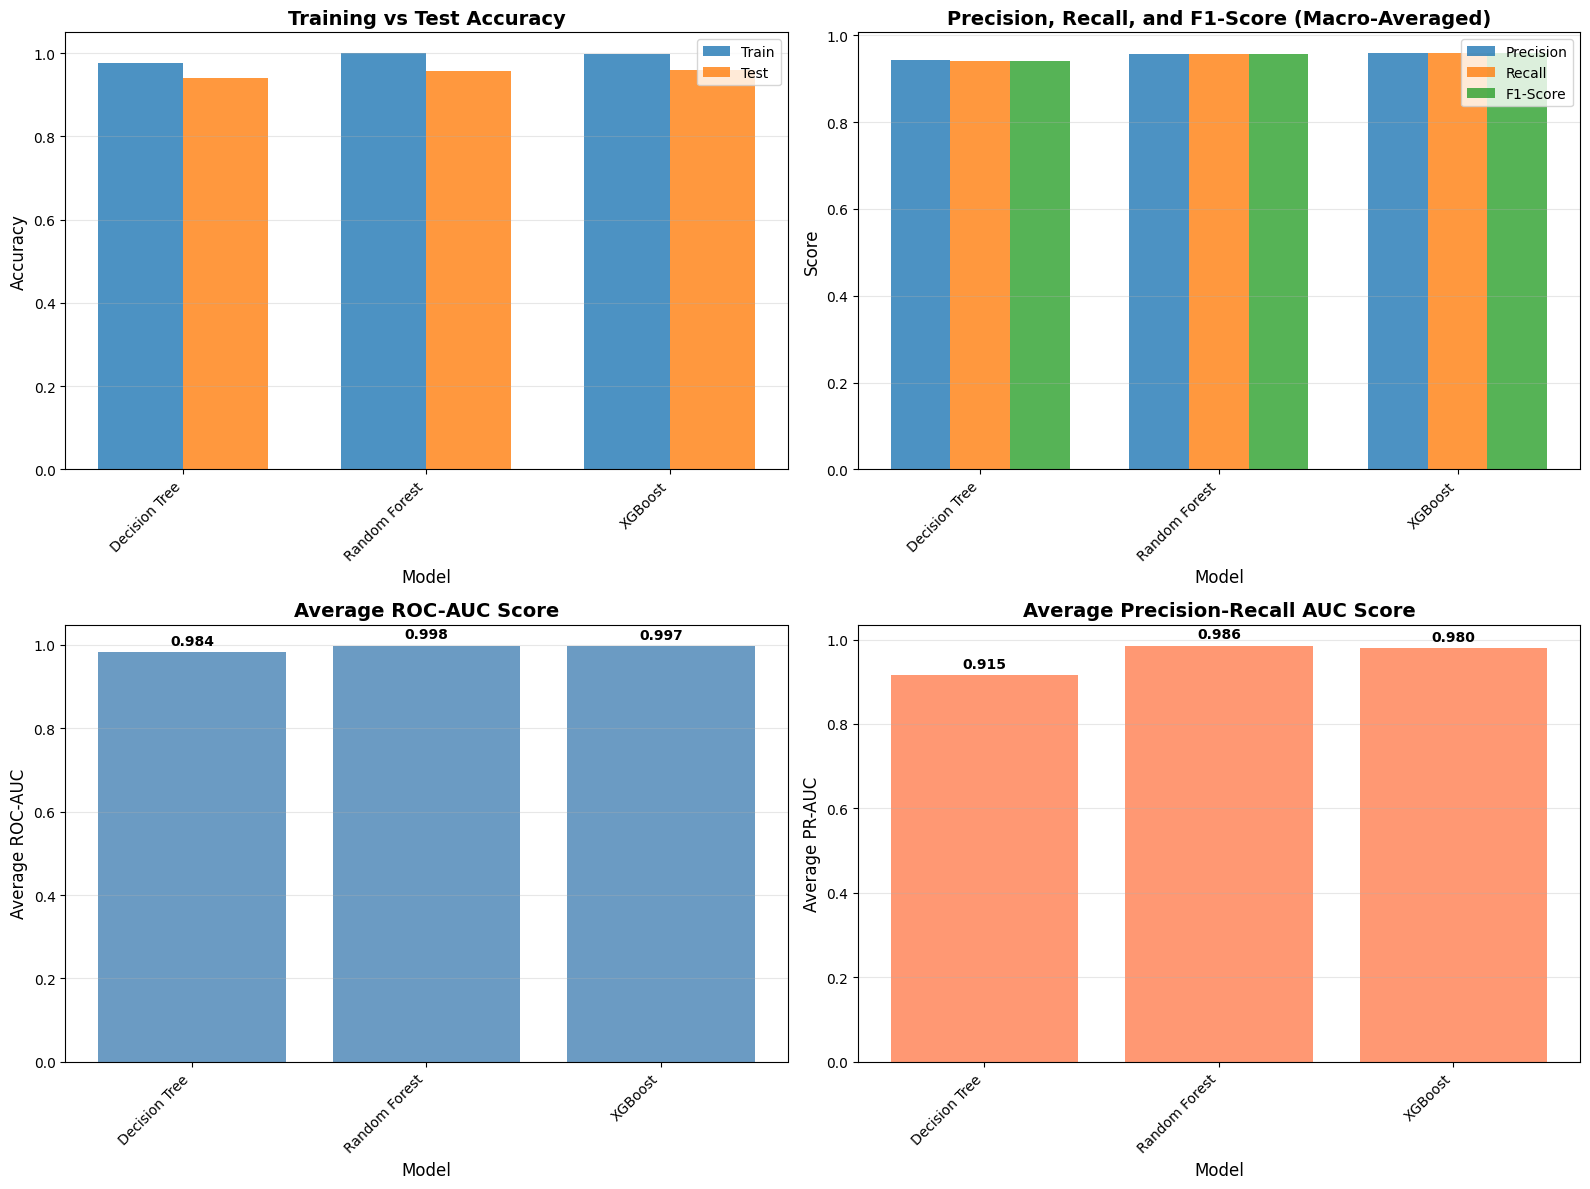

In [32]:
# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Macro-averaged metrics
dt_precision = precision_score(y_test, dt_test_pred, average='macro', zero_division=0)
dt_recall = recall_score(y_test, dt_test_pred, average='macro', zero_division=0)
dt_f1 = f1_score(y_test, dt_test_pred, average='macro', zero_division=0)

rf_precision = precision_score(y_test, rf_test_pred, average='macro', zero_division=0)
rf_recall = recall_score(y_test, rf_test_pred, average='macro', zero_division=0)
rf_f1 = f1_score(y_test, rf_test_pred, average='macro', zero_division=0)

xgb_precision = precision_score(y_test, xgb_test_pred, average='macro', zero_division=0)
xgb_recall = recall_score(y_test, xgb_test_pred, average='macro', zero_division=0)
xgb_f1 = f1_score(y_test, xgb_test_pred, average='macro', zero_division=0)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Test Accuracy': [dt_test_acc, rf_test_acc, xgb_test_acc],
    'Train Accuracy': [dt_train_acc, rf_train_acc, xgb_train_acc],
    'Precision (Macro)': [dt_precision, rf_precision, xgb_precision],
    'Recall (Macro)': [dt_recall, rf_recall, xgb_recall],
    'F1-Score (Macro)': [dt_f1, rf_f1, xgb_f1],
    'ROC-AUC (Avg)': [np.mean(list(roc_auc_dt.values())), 
                      np.mean(list(roc_auc_rf.values())), 
                      np.mean(list(roc_auc_xgb.values()))],
    'PR-AUC (Avg)': [np.mean(list(pr_auc_dt.values())), 
                     np.mean(list(pr_auc_rf.values())), 
                     np.mean(list(pr_auc_xgb.values()))]
})

# Round to 4 decimal places
comparison_df = comparison_df.round(4)

print("\n" + "="*100)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy comparison
ax = axes[0, 0]
x = np.arange(len(comparison_df))
width = 0.35
ax.bar(x - width/2, comparison_df['Train Accuracy'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Training vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Precision, Recall, F1 comparison
ax = axes[0, 1]
x = np.arange(len(comparison_df))
width = 0.25
ax.bar(x - width, comparison_df['Precision (Macro)'], width, label='Precision', alpha=0.8)
ax.bar(x, comparison_df['Recall (Macro)'], width, label='Recall', alpha=0.8)
ax.bar(x + width, comparison_df['F1-Score (Macro)'], width, label='F1-Score', alpha=0.8)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, and F1-Score (Macro-Averaged)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ROC-AUC comparison
ax = axes[1, 0]
ax.bar(comparison_df['Model'], comparison_df['ROC-AUC (Avg)'], alpha=0.8, color='steelblue')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Average ROC-AUC', fontsize=12)
ax.set_title('Average ROC-AUC Score', fontsize=14, fontweight='bold')
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['ROC-AUC (Avg)']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# PR-AUC comparison
ax = axes[1, 1]
ax.bar(comparison_df['Model'], comparison_df['PR-AUC (Avg)'], alpha=0.8, color='coral')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Average PR-AUC', fontsize=12)
ax.set_title('Average Precision-Recall AUC Score', fontsize=14, fontweight='bold')
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['PR-AUC (Avg)']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Analisis Misklasifikasi

Analisis detail tentang kesalahan klasifikasi untuk memahami pola kesalahan dan kelas yang paling sulit dibedakan.


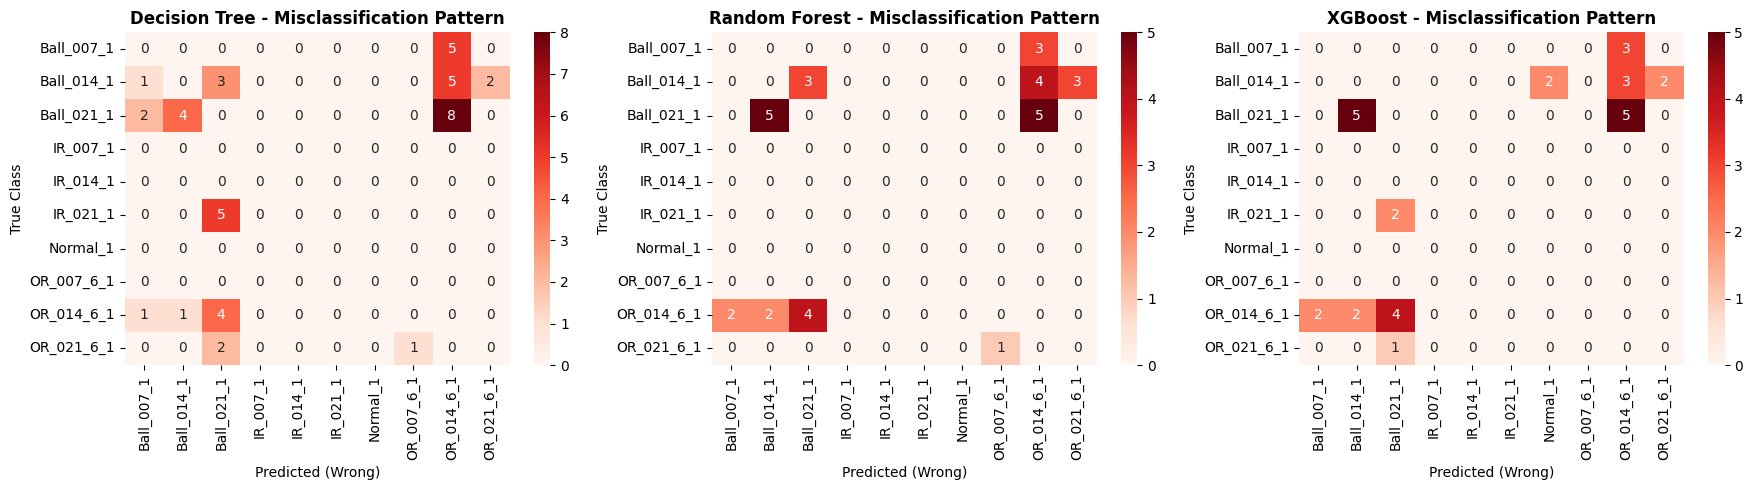


MISCLASSIFICATION ANALYSIS

Decision Tree - Misclassifications per True Class:
  Ball_021_1: 14 misclassifications
  Ball_014_1: 11 misclassifications
  OR_014_6_1: 6 misclassifications
  Ball_007_1: 5 misclassifications
  IR_021_1: 5 misclassifications
  OR_021_6_1: 3 misclassifications

Random Forest - Misclassifications per True Class:
  Ball_014_1: 10 misclassifications
  Ball_021_1: 10 misclassifications
  OR_014_6_1: 8 misclassifications
  Ball_007_1: 3 misclassifications
  OR_021_6_1: 1 misclassifications

XGBoost - Misclassifications per True Class:
  Ball_021_1: 10 misclassifications
  OR_014_6_1: 8 misclassifications
  Ball_014_1: 7 misclassifications
  Ball_007_1: 3 misclassifications
  IR_021_1: 2 misclassifications
  OR_021_6_1: 1 misclassifications


In [33]:
# Analyze misclassifications for each model
def analyze_misclassifications(y_true, y_pred, model_name, fault_labels):
    """Analyze and visualize misclassifications"""
    misclass_mask = y_true != y_pred
    misclass_true = y_true[misclass_mask]
    misclass_pred = y_pred[misclass_mask]
    
    # Create confusion matrix for misclassifications only
    misclass_cm = confusion_matrix(misclass_true, misclass_pred, labels=np.arange(len(fault_labels)))
    
    # Count misclassifications per true class
    misclass_per_class = {}
    for i, label in enumerate(fault_labels):
        count = np.sum(misclass_true == i)
        misclass_per_class[label] = count
    
    return misclass_cm, misclass_per_class, misclass_true, misclass_pred

# Analyze for all models
dt_misclass_cm, dt_misclass_per_class, dt_misclass_true, dt_misclass_pred = analyze_misclassifications(
    y_test, dt_test_pred, "Decision Tree", fault_type)
rf_misclass_cm, rf_misclass_per_class, rf_misclass_true, rf_misclass_pred = analyze_misclassifications(
    y_test, rf_test_pred, "Random Forest", fault_type)
xgb_misclass_cm, xgb_misclass_per_class, xgb_misclass_true, xgb_misclass_pred = analyze_misclassifications(
    y_test, xgb_test_pred, "XGBoost", fault_type)

# Visualize misclassification patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree misclassifications
sns.heatmap(dt_misclass_cm, annot=True, fmt="d", cmap="Reds", ax=axes[0],
            xticklabels=fault_type, yticklabels=fault_type, cbar=True)
axes[0].set_title('Decision Tree - Misclassification Pattern', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted (Wrong)', fontsize=10)
axes[0].set_ylabel('True Class', fontsize=10)

# Random Forest misclassifications
sns.heatmap(rf_misclass_cm, annot=True, fmt="d", cmap="Reds", ax=axes[1],
            xticklabels=fault_type, yticklabels=fault_type, cbar=True)
axes[1].set_title('Random Forest - Misclassification Pattern', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted (Wrong)', fontsize=10)
axes[1].set_ylabel('True Class', fontsize=10)

# XGBoost misclassifications
sns.heatmap(xgb_misclass_cm, annot=True, fmt="d", cmap="Reds", ax=axes[2],
            xticklabels=fault_type, yticklabels=fault_type, cbar=True)
axes[2].set_title('XGBoost - Misclassification Pattern', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted (Wrong)', fontsize=10)
axes[2].set_ylabel('True Class', fontsize=10)

plt.tight_layout()
plt.show()

# Print misclassification summary
print("\n" + "="*70)
print("MISCLASSIFICATION ANALYSIS")
print("="*70)

print("\nDecision Tree - Misclassifications per True Class:")
for label, count in sorted(dt_misclass_per_class.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {label}: {count} misclassifications")

print("\nRandom Forest - Misclassifications per True Class:")
for label, count in sorted(rf_misclass_per_class.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {label}: {count} misclassifications")

print("\nXGBoost - Misclassifications per True Class:")
for label, count in sorted(xgb_misclass_per_class.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {label}: {count} misclassifications")
print("="*70)


## Perbandingan Kepentingan Fitur Menggunakan SHAP

Membandingkan kepentingan fitur dari ketiga model menggunakan SHAP values untuk memahami konsistensi dan perbedaan antar model.



SHAP FEATURE IMPORTANCE COMPARISON (Normalized to 0-100%)
 Feature  Decision Tree_Normalized  Random Forest_Normalized  XGBoost_Normalized  Average_Normalized
    mean                 58.472614                100.000000           88.299904           82.257506
      sd                  5.462966                 98.804110          100.000000           68.089025
     rms                100.000000                 82.891674           13.927579           65.606418
kurtosis                 37.013525                 64.785758           79.773804           60.524362
     min                 52.175159                 66.810800           24.910057           47.965339
    form                 13.678153                 50.955970           66.222916           43.619013
     max                  0.852940                 39.237704           43.594761           27.895135
   crest                  0.746354                 27.536551           12.812093           13.698333
skewness                  0.1590

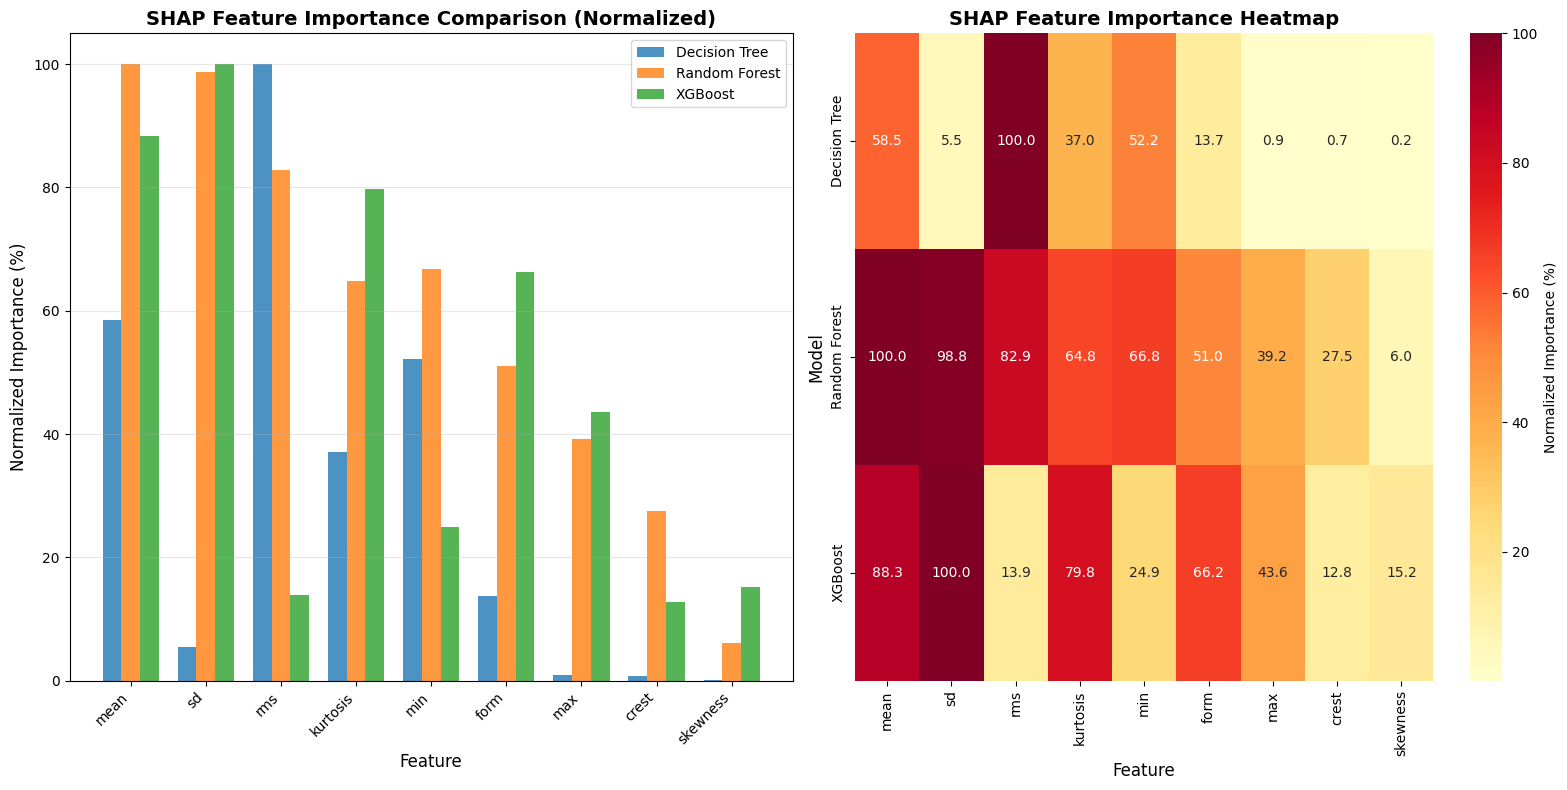

In [34]:
# Extract feature importance from SHAP values for comparison
def get_shap_importance(shap_values, feature_names):
    """Extract mean absolute SHAP values as feature importance"""
    if isinstance(shap_values, list):
        # Multi-class: list of arrays
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        # Single output or binary
        if len(shap_values.shape) == 3:
            mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
        else:
            mean_abs_shap = np.abs(shap_values).mean(axis=0)
    return mean_abs_shap

# Get feature importance for all models
dt_shap_importance = get_shap_importance(shap_values_dt, feature_names)
rf_shap_importance = get_shap_importance(shap_values_rf, feature_names)
xgb_shap_importance = get_shap_importance(shap_values_xgb, feature_names)

# Create comparison DataFrame
shap_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Decision Tree': dt_shap_importance,
    'Random Forest': rf_shap_importance,
    'XGBoost': xgb_shap_importance
})

# Normalize to percentage for easier comparison
for col in ['Decision Tree', 'Random Forest', 'XGBoost']:
    shap_comparison[f'{col}_Normalized'] = (shap_comparison[col] / shap_comparison[col].max()) * 100

# Sort by average importance
shap_comparison['Average_Normalized'] = shap_comparison[['Decision Tree_Normalized', 
                                                          'Random Forest_Normalized', 
                                                          'XGBoost_Normalized']].mean(axis=1)
shap_comparison = shap_comparison.sort_values('Average_Normalized', ascending=False)

print("\n" + "="*100)
print("SHAP FEATURE IMPORTANCE COMPARISON (Normalized to 0-100%)")
print("="*100)
print(shap_comparison[['Feature', 'Decision Tree_Normalized', 'Random Forest_Normalized', 
                       'XGBoost_Normalized', 'Average_Normalized']].to_string(index=False))
print("="*100)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart comparison
ax = axes[0]
x = np.arange(len(shap_comparison))
width = 0.25
ax.bar(x - width, shap_comparison['Decision Tree_Normalized'], width, label='Decision Tree', alpha=0.8)
ax.bar(x, shap_comparison['Random Forest_Normalized'], width, label='Random Forest', alpha=0.8)
ax.bar(x + width, shap_comparison['XGBoost_Normalized'], width, label='XGBoost', alpha=0.8)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Normalized Importance (%)', fontsize=12)
ax.set_title('SHAP Feature Importance Comparison (Normalized)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(shap_comparison['Feature'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Heatmap of normalized importance
ax = axes[1]
heatmap_data = shap_comparison[['Decision Tree_Normalized', 'Random Forest_Normalized', 
                                'XGBoost_Normalized']].T
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            xticklabels=shap_comparison['Feature'], yticklabels=['Decision Tree', 'Random Forest', 'XGBoost'],
            cbar_kws={'label': 'Normalized Importance (%)'})
ax.set_title('SHAP Feature Importance Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()


### Analisis SHAP per Jenis Kerusakan

Menganalisis kepentingan fitur untuk setiap jenis kerusakan secara spesifik untuk memahami pola unik setiap kerusakan.



Analyzing SHAP values per fault type for: XGBoost


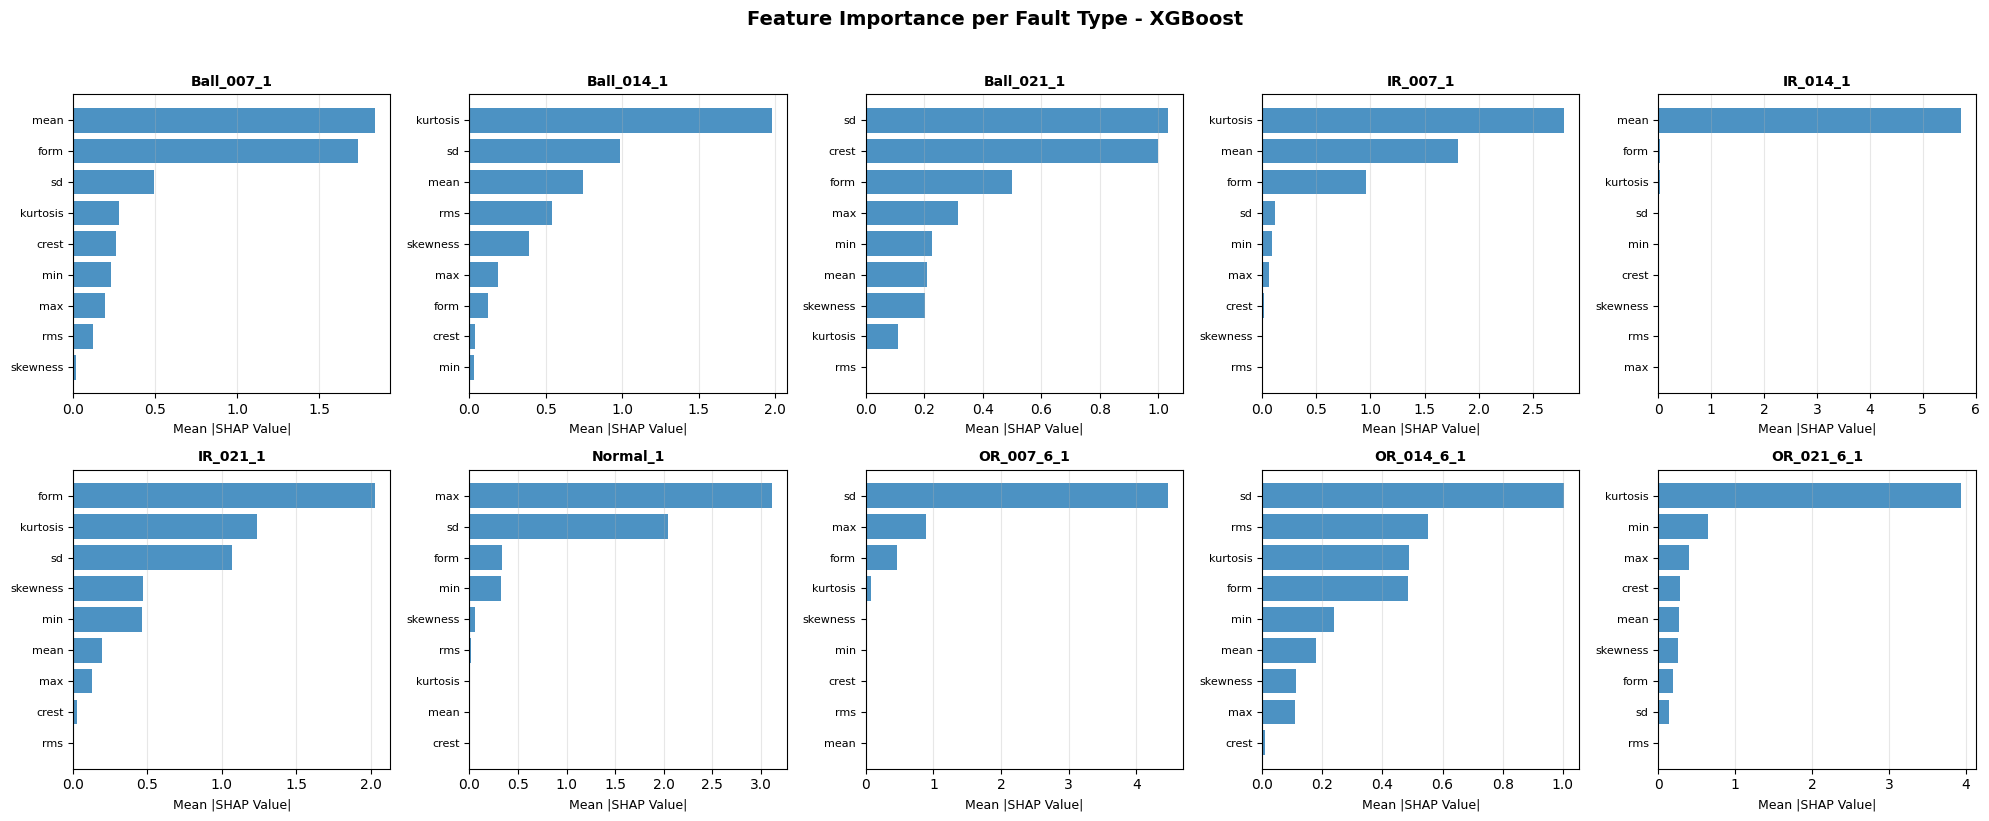


TOP 3 FEATURES PER FAULT TYPE (XGBoost)

Ball_007_1:
  1. mean: 1.8431
  2. form: 1.7386
  3. sd: 0.4907

Ball_014_1:
  1. kurtosis: 1.9786
  2. sd: 0.9890
  3. mean: 0.7448

Ball_021_1:
  1. sd: 1.0337
  2. crest: 0.9986
  3. form: 0.5009

IR_007_1:
  1. kurtosis: 2.7913
  2. mean: 1.8063
  3. form: 0.9580

IR_014_1:
  1. mean: 5.7182
  2. form: 0.0337
  3. kurtosis: 0.0328

IR_021_1:
  1. form: 2.0311
  2. kurtosis: 1.2386
  3. sd: 1.0668

Normal_1:
  1. max: 3.1116
  2. sd: 2.0490
  3. form: 0.3357

OR_007_6_1:
  1. sd: 4.4683
  2. max: 0.8961
  3. form: 0.4602

OR_014_6_1:
  1. sd: 1.0047
  2. rms: 0.5525
  3. kurtosis: 0.4900

OR_021_6_1:
  1. kurtosis: 3.9325
  2. min: 0.6436
  3. max: 0.4029


In [35]:
# Analyze SHAP values per fault type for the best performing model
# Let's use Random Forest as it typically performs well
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\nAnalyzing SHAP values per fault type for: {best_model_name}")

# Get the best model's SHAP values
if best_model_name == 'Decision Tree':
    best_shap_values = shap_values_dt
elif best_model_name == 'Random Forest':
    best_shap_values = shap_values_rf
else:
    best_shap_values = shap_values_xgb

# Get true labels for the SHAP sample
test_sample_labels = y_test[test_sample_indices]

# Analyze per fault type
fault_shap_analysis = {}
for fault_idx, fault_name in enumerate(fault_type):
    # Find samples of this fault type in the SHAP sample
    fault_mask = test_sample_labels == fault_idx
    if np.sum(fault_mask) > 0:
        if isinstance(best_shap_values, list):
            # Multi-class: get SHAP values for this class
            fault_shap = best_shap_values[fault_idx][fault_mask]
        else:
            # 3D array: (samples, features, classes)
            if len(best_shap_values.shape) == 3:
                fault_shap = best_shap_values[fault_mask, :, fault_idx]
            else:
                fault_shap = best_shap_values[fault_mask]
        
        # Calculate mean absolute SHAP per feature
        mean_abs_shap = np.abs(fault_shap).mean(axis=0)
        fault_shap_analysis[fault_name] = mean_abs_shap

# Create visualization
n_faults = len(fault_shap_analysis)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (fault_name, importance) in enumerate(fault_shap_analysis.items()):
    ax = axes[idx]
    sorted_idx = np.argsort(importance)
    ax.barh(range(len(feature_names)), importance[sorted_idx], alpha=0.8)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=8)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=9)
    ax.set_title(f'{fault_name}', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(f'Feature Importance per Fault Type - {best_model_name}', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print top features for each fault type
print("\n" + "="*70)
print(f"TOP 3 FEATURES PER FAULT TYPE ({best_model_name})")
print("="*70)
for fault_name, importance in fault_shap_analysis.items():
    top3_idx = np.argsort(importance)[-3:][::-1]
    print(f"\n{fault_name}:")
    for i, feat_idx in enumerate(top3_idx, 1):
        print(f"  {i}. {feature_names[feat_idx]}: {importance[feat_idx]:.4f}")
print("="*70)


## Kesimpulan dan Temuan Utama

Berdasarkan analisis komprehensif yang telah dilakukan, berikut adalah kesimpulan dan temuan utama


In [37]:
# Generate comprehensive insights
print("="*70)
print("KESIMPULAN DAN TEMUAN UTAMA")
print("="*70)

# Best model
best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Test Accuracy']

print(f"\n1. MODEL TERBAIK:")
print(f"   {best_model} mencapai akurasi test tertinggi: {best_accuracy:.4f}")
print(f"   - Precision (Macro): {comparison_df.loc[best_model_idx, 'Precision (Macro)']:.4f}")
print(f"   - Recall (Macro): {comparison_df.loc[best_model_idx, 'Recall (Macro)']:.4f}")
print(f"   - F1-Score (Macro): {comparison_df.loc[best_model_idx, 'F1-Score (Macro)']:.4f}")
print(f"   - ROC-AUC (Avg): {comparison_df.loc[best_model_idx, 'ROC-AUC (Avg)']:.4f}")
print(f"   - PR-AUC (Avg): {comparison_df.loc[best_model_idx, 'PR-AUC (Avg)']:.4f}")

# Feature importance insights
top_features = shap_comparison.head(5)
print(f"\n2. FITUR PALING PENTING (Berdasarkan Rata-rata SHAP):")
for idx, row in top_features.iterrows():
    print(f"   {row['Feature']}: {row['Average_Normalized']:.1f}% (normalized)")

# Consistency across models
feature_std = shap_comparison[['Decision Tree_Normalized', 'Random Forest_Normalized', 
                                'XGBoost_Normalized']].std(axis=1)
most_consistent = shap_comparison.loc[feature_std.idxmin(), 'Feature']
print(f"\n3. KONSISTENSI ANTAR MODEL:")
print(f"   Fitur yang paling konsisten: {most_consistent}")
print(f"   (Standar deviasi terendah: {feature_std.min():.2f}%)")

# Misclassification insights
total_misclass_dt = len(y_test) - int(dt_test_acc * len(y_test))
total_misclass_rf = len(y_test) - int(rf_test_acc * len(y_test))
total_misclass_xgb = len(y_test) - int(xgb_test_acc * len(y_test))
min_misclass = min(total_misclass_dt, total_misclass_rf, total_misclass_xgb)

print(f"\n4. ANALISIS MISKLASIFIKASI:")
print(f"   Total misclassifications:")
print(f"   - Decision Tree: {total_misclass_dt}")
print(f"   - Random Forest: {total_misclass_rf}")
print(f"   - XGBoost: {total_misclass_xgb}")
print(f"   Model dengan misclassifications terendah: {best_model} ({min_misclass} errors)")

# Overfitting analysis
overfitting_dt = dt_train_acc - dt_test_acc
overfitting_rf = rf_train_acc - rf_test_acc
overfitting_xgb = xgb_train_acc - xgb_test_acc

print(f"\n5. ANALISIS OVERFITTING (Train Acc - Test Acc):")
print(f"   - Decision Tree: {overfitting_dt:.4f}")
print(f"   - Random Forest: {overfitting_rf:.4f}")
print(f"   - XGBoost: {overfitting_xgb:.4f}")
if overfitting_dt < 0.05 and overfitting_rf < 0.05 and overfitting_xgb < 0.05:
    print("   ✓ Semua model menunjukkan generalisasi yang baik (overfitting < 5%)")
else:
    print("   ⚠ Beberapa model menunjukkan tanda-tanda overfitting")

print("\n" + "="*70)
print("REKOMENDASI:")
print("="*70)
print("1. Gunakan model dengan performa terbaik untuk aplikasi praktis")
print("2. Fokus pada fitur-fitur dengan kepentingan tinggi untuk monitoring")
print("3. Perhatikan kelas-kelas dengan misclassifications tinggi untuk perbaikan")
print("4. Pertimbangkan ensemble methods untuk meningkatkan robustnes")
print("="*70)


KESIMPULAN DAN TEMUAN UTAMA

1. MODEL TERBAIK:
   XGBoost mencapai akurasi test tertinggi: 0.9587
   - Precision (Macro): 0.9589
   - Recall (Macro): 0.9587
   - F1-Score (Macro): 0.9587
   - ROC-AUC (Avg): 0.9971
   - PR-AUC (Avg): 0.9799

2. FITUR PALING PENTING (Berdasarkan Rata-rata SHAP):
   mean: 82.3% (normalized)
   sd: 68.1% (normalized)
   rms: 65.6% (normalized)
   kurtosis: 60.5% (normalized)
   min: 48.0% (normalized)

3. KONSISTENSI ANTAR MODEL:
   Fitur yang paling konsisten: skewness
   (Standar deviasi terendah: 7.57%)

4. ANALISIS MISKLASIFIKASI:
   Total misclassifications:
   - Decision Tree: 44
   - Random Forest: 32
   - XGBoost: 31
   Model dengan misclassifications terendah: XGBoost (31 errors)

5. ANALISIS OVERFITTING (Train Acc - Test Acc):
   - Decision Tree: 0.0348
   - Random Forest: 0.0427
   - XGBoost: 0.0388
   ✓ Semua model menunjukkan generalisasi yang baik (overfitting < 5%)

REKOMENDASI:
1. Gunakan model dengan performa terbaik untuk aplikasi praktis